# **Tutorial 2** $\cdot$ Structure Attribution Methods

> **Abstract.** This tutorial introduces *structure-attribution methods* for explaining graph neural network (GNN) predictions in molecular property prediction. Unlike feature-attribution methods that assign importance to abstract descriptors, structure-attribution methods highlight the specific atoms and bonds within a molecule that drive the model's predictions &mdash; providing direct insight into structure-activity relationships (SAR). We demonstrate four complementary approaches: (1) **GNNExplainer**, a perturbation-based method that optimizes masks to identify important substructures; (2) **PGExplainer**, a parameterized approach that trains a neural network to predict edge importance across the dataset; (3) **Myerson values**, a game-theoretic method grounded in cooperative game theory that provides theoretically justified attributions; and (4) **MEGAN**, a self-explaining graph attention network that produces multi-channel explanations as an intrinsic part of its forward pass. Using the Ames mutagenicity dataset as a case study, we train GNN models, generate explanations with each method, and compare their outputs side-by-side. The tutorial highlights how different methods can agree on chemically meaningful substructures (such as nitro groups) while also revealing complementary perspectives on model behavior.

**💾 Dataset.** This tutorial uses the *Ames Mutagenicity* dataset, a binary classification benchmark for predicting whether compounds exhibit mutagenic activity in the Ames bacterial reverse mutation assay. The dataset contains diverse organic molecules labeled as mutagenic (positive) or non-mutagenic (negative), making it well-suited for demonstrating structure-attribution methods that can highlight known mutagenic structural alerts.

**📦 Packages.** Packages used in this notebook include:
- [RDKit](https://www.rdkit.org/docs/index.html) Cheminformatics framework for processing of SMILES strings and the calculation of molecular descriptors and fingerprints.
- [Pandas](https://pandas.pydata.org/docs/index.html) for data representation and processing.
- [Pytorch](https://docs.pytorch.org/docs/stable/index.html) and [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) for the training of simple neural network models based on the molecular representations.
- [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) framework for the construction, training and explanation of graph neural network (GNN)-based property prediction models.
- [NetworkX](https://networkx.org/) for the representation and visualization of graph structured data.
- [myerson](https://github.com/kochgroup/myerson) for computing Myerson value explanations based on cooperative game theory.
- [graph_attention_student](https://github.com/aimat-lab/graph_attention_student) for MEGAN, a self-explaining graph attention network with built-in multi-channel explanations.

In [282]:
import os
import random

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import pytorch_lightning as pl
import torch.nn as nn
import torch.nn.functional as F
import rdkit.Chem as Chem
from rdkit import RDLogger
from rich.pretty import pprint
from torch.utils.data import TensorDataset
from torch.utils.data import Subset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torchmetrics import Accuracy, F1Score

from xai_chem_review import load_dataset_mutagenicity

# Set the matplotlib style
plt.style.use('default')
# Disable all RDKit warnings
RDLogger.DisableLog('rdApp.*')

In [283]:
data_frame: pd.DataFrame = load_dataset_mutagenicity()
print(f'Loaded dataset with {data_frame.shape[0]} rows')
data_frame.head()

Loaded dataset with 6512 rows


,CAS_NO,Activity,smiles
0,2475-33-4,0,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...
1,820-75-7,1,N#C/N=C/C(=O)NCC(=O)NN
2,2435-76-9,1,N#C/N=C1/C=NC(=O)NC1=O
3,817-99-2,1,N#C/N=C/C(=O)NCC(N)=O
4,116539-70-9,1,CCCCN(CC(O)C1=C/C(=N\C#N)C(=O)C=C1)N=O


## **2.1** $\cdot$ 💡 Structure-Attributional Explanations

Unlike the previously showcased methods, structure-attribution methods operate on the level of *graph structure*. Rather than attributing importance to abstract features (e.g. molecular weight), importance scores are computed for the individual elements of the molecular graph &mdash; namely its nodes (atoms) and edges (bonds). By highlighting important nodes and edges, these methods represent a view on the  structure-activity relationships (SAR) underlying the model's predictive decisions.

One primary difference between the two types of attributional explanations is the choice of the underlying model. Feature-attibutional explanations can be more easily obtained from models which directly use these features as the basis of their predictions. As shown in the previous tutorial, simple predictive models based on molecular descriptors can be used to generate such explanations. On the contrary, structure-attributional explanations can be more easily obtained through the use of *graph neural networks (GNNs)*. Instead of a fixed-size vector input, these GNN models operate directly on the abstract graph representation of the molecule. Due to their different operating principles, most explainability methods wont be directly applicable to graph neural networks. Although many methods (including SHAP and LIME) have been adpated to work with graph neural networks as well, there also exist a plethora of approaches designed to generate explanations specifically for GNNs.

## **2.2** $\cdot$ 📚 *Graph Neural Network Explainer* (`GNNExplainer`)

The first example method from the literature was proposed by [Ying *et al.*](https://arxiv.org/abs/1903.03894) in 2019 and is called *GNNExplainer*. The method is based on the idea of using input perturbations to extract those parts of the graph structure which are the most important for a given model prediction. For a given graph structure and it's original prediction, each explanation is created by optimizing the weights of a mask over the given graph. The components of the mask correspond to the individual elements of the graph (nodes and edges) and their 0 to 1 values determine if the model is able to "see" the element (=1) or not (=0) during it's prediction. In the process of multiple predictions, the components of the mask are then adjusted such that a large part of the graph is "hidden" from the model while changing the model's *prediction* as little as possible. Therefore, the final optimized mask shows the subset of nodes and edges most important to the model to form it's decision.

**Implementation.** To use GNNExplainer, we'll first have to train a graph neural network, which will be done with the popular [Pytorch Geometric (PyG)](https://pytorch-geometric.readthedocs.io/en/latest/) framework. Aside from various GNN architectures themselves, PyG has since also implemented the ``torch_geometric.explain`` package which offers existing implementations of some common graph explanation methods - including GNNExplainer.

### Molecular Graph Processing

As previously introduced, we want to use a graph neural network based on the popular [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) library for our main property prediction model. Do do molecular property prediction, such a GNN model needs to receive the various molecules in a *graph representation*. As a very first step, before implementing the model itself, we therefore have to construct a data-processing pipeline that can be used to convert the molecules into these graph representaitons.

**Graph Representation.** On a technical level, a PyG GNN model will need to receive the graphs in the format of a `torch_geometric.data.Data` object. A first option would be to write some function `data_from_smiles` which converts a given SMILES representation of a molecule into such a `Data` object. However, as in the previous notebook, it also makes sense to invest more thought about how the graph-based explanations will be visualized later on. For the processing and handling of graphs there already exists very useful python package called `networkx`. This package also has lots of *built-in* functionality for the manipulation and visualization of these graphs which will be useful for the explanations later on. Consequently, a good option would be to use the `networkx.Graph` object as an *intermediate representation* - based on which the visualization can be handled more easily later on. Using this intermediate representation we'll therefore have to create two seperate functions `graph_from_smiles` and `data_from_graph`.

**Feature Extraction.** When converting a molecule into a machine-readable graph representation, another question that comes up is that of feature extraction. However, unlike with molecular descriptors the feature extraction in this case will have to be done on the level of individual atoms and bonds &mdash; rather than on the level of the entire molecule. When a GNN model is creating a prediction based on the graph structure of a molecule, each node and edge of this graph need to contain some form of vectorized information about whether a node represents a carbon or an oxygen atom, for example. We therefore need to implement two additional functions `encode_atom(atom: Chem.Atom) -> np.ndarray` and `encode_bond(bond:Chem.Bond) -> np.ndarray` which can be used to calculate these numeric feature vectors corresponding to the individual nodes and atoms.

In [284]:
def encode_atom(atom: Chem.Atom,
                supported_atoms: list[str] = ['C', 'N', 'O', 'S', 'P', 'Cl', 'Br', 'F'],
                ) -> np.ndarray:
    """
    Encodes a given RDKit `atom` object into a fixed-size vector representation of its properties - including 
    a one-hot encoding of the atom type, as well as information about the atom's valence and charge.
    
    :param atom: The Chem.Atom object to be converted.
    :param supported_atoms: A list of atom symbols that are supported for the one-hot encoding. 
        If the given atom's symbol is not in this list, it will be marked as unknown which is 
        an additional one-hot encoded quantity in the output vector.
        
    :return: A numpy array of shape (n_feature, ) containing the encoded atom properties.
    """
    
    # The first part of the encoded vector is a one-hot representation of the atom type. Note that only 
    # the subset of atoms defined in the `supported_atoms` list will supported for explicit encoding. 
    # If the atom's symbol is not in this list, it will be marked as unknown, which is another additional
    # one-hot encoded quantity in the output vector.
    atom_one_hot = np.zeros(len(supported_atoms), dtype = np.float32)
    if atom.GetSymbol() in supported_atoms:
        atom_one_hot[supported_atoms.index(atom.GetSymbol())] = 1.0
    
    atom_unknown = float(atom.GetSymbol() not in supported_atoms)
    
    # Additionally, we want to provide information about the atom valence and charge, as this information 
    # will also implicitly communicate the number of implicitly attached hydrogens to the atom.
    atom_valence = atom.GetTotalValence()
    atom_valence_implicit = atom.GetImplicitValence()
    atom_charge = atom.GetFormalCharge()
    
    # Finally, we package the information into a single numeric vector
    return np.array([
        *atom_one_hot,
        atom_unknown,
        atom_valence,
        atom_valence_implicit,
        atom_charge,
    ], dtype = np.float32)


def encode_bond(bond: Chem.Bond,
                supported_bond_types: list[int] = [
                    Chem.BondType.SINGLE, 
                    Chem.BondType.DOUBLE, 
                    Chem.BondType.TRIPLE, 
                ],
                ) -> np.ndarray:
    """
    Encodes a given RDKit `bond` object into a fixed-size vector representation of its properties - including
    a one-hot encoding of the bond type, as well as information about the bond's stereo configuration and whether it is aromatic.
    
    :param bond: The Chem.Bond object to be converted.
    :param supported_bond_types: A list of bond types that are supported for the one-hot encoding. 
    
    :return: A numpy array of shape (n_feature, ) containing the encoded bond properties.
    """
    # The first part of the encoded vector is a one-hot representation of the bond type.
    # Note that only the subset of bond types defined in the `supported_bond_types` list will supported for explicit encoding. 
    # If the bond type is not in this list, it will be marked as unknown, which is another additional
    # one-hot encoded quantity in the output vector.
    bond_type_one_hot = np.zeros(len(supported_bond_types), dtype = np.float32)
    if bond.GetBondType() in supported_bond_types:
        bond_type_one_hot[supported_bond_types.index(bond.GetBondType())] = 1.0
        
    bond_unknown = float(bond.GetBondType() not in supported_bond_types)
    
    # Additionally, we want to provide information about the bond's stereo configuration and whether it is aromatic.
    bond_stereo = bond.GetStereo()
    bond_aromatic = float(bond.GetIsAromatic())
    
    return np.array([
        *bond_type_one_hot,
        bond_unknown,
        bond_stereo,
        bond_aromatic,
    ], dtype = np.float32)


**Example Node and Edge Encoding.** After defining these two functions we can look at an example of how they work. For this purpose we will create two artificial objects &mdash; one <code>Atom</code> and one <code>Bond</code> object &mdash; and then apply the feature extraction functions on those to see what the results look like.

In [285]:
# We use a single carbon atom as the example.
example_atom: Chem.Atom = Chem.Atom('C')
atom_features: np.ndarray = encode_atom(example_atom)

print('Atom (C)')
print('========')
print(f'{type(example_atom).__name__} object: {example_atom}')
print(f'Atom Features: {atom_features}')
features = ['is carbon?', 'is nitrogen?', 'is oxygen?', 'is sulfur?',
            'is phosphor?', 'is chlorine?', 'is bromine?', 'is flourine?',
            'is other?']
for feature, value in zip(features, atom_features):
    print(f'{feature.ljust(20)} - {bool(value)}') 
print()

# For the bond, we look at a simple bond between a carbon and and an oxygen atom.
# Constructing a standalone bond is a little bit more complicated than an atom. To 
# get the bond we first have to initialize an "empty" molecule to which we than add 
# the bond.
mol_rw = Chem.RWMol()
c_idx = mol_rw.AddAtom(Chem.Atom('C'))
n_idx = mol_rw.AddAtom(Chem.Atom('N'))
mol_rw.AddBond(c_idx, n_idx, Chem.BondType.SINGLE)

example_bond: Chem.Bond = mol_rw.GetBondWithIdx(0)
bond_features: np.ndarray = encode_bond(example_bond)

print('Bond (C-O)')
print('==========')
print(f'{type(example_bond).__name__} object: {example_bond}')
print(f'Bond Features: {bond_features}')
features = ['is single bond?', 'is double bond?', 'is triple?', 'is other?',
            'is stereo?', 'is aromatic?']
for feature, value in zip(features, atom_features):
    print(f'{feature.ljust(20)} - {bool(value)}') 
print()

Atom (C)
Atom object: <rdkit.Chem.rdchem.Atom object at 0x790b464cd6c0>
Atom Features: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
is carbon?           - True
is nitrogen?         - False
is oxygen?           - False
is sulfur?           - False
is phosphor?         - False
is chlorine?         - False
is bromine?          - False
is flourine?         - False
is other?            - False

Bond (C-O)
Bond object: <rdkit.Chem.rdchem.Bond object at 0x790d2ecfde00>
Bond Features: [1. 0. 0. 0. 0. 0.]
is single bond?      - True
is double bond?      - False
is triple?           - False
is other?            - False
is stereo?           - False
is aromatic?         - False



**🔍 Atom and Bond Features.** As we can see, each atom and each bond can be mapped into a numeric vector which describes its most important properties. How exactly this vector is structured is up to the developer and can be considered as part of a hyperparameter optimization.

<details style="border: 1.5px #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 Different Feature Representations</summary>

Aside from <em>which</em> features to inlcude, another question may be <em>how</em> to best represent them. 
</details>

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 2.1** $\cdot$ As you can see, the individual atoms of a molecule are represented by a relatively small number of features. Only a handful of the most frequent atom types are explicitly covered (C, N, O, ...). Atoms with any other type than the ones explicitly covered would all fall under the umbrella class of "other" types. Consequently, all of these atoms would <em>"look the same"</em> to the model. The choice of which types, or more generally which features, to include also heavily depends on the target domain. Applications in small molecule organic chemistry will most likely require different features than something like catalyst activity prediction.

As an exercise, try to extend the atom feature vector to also include <em>iodine</em> and <em>magnesium</em> as explicitly handled atom types. Also think about which subsequent code you'll have to adjust as a consequence of such as change.
</div>

**Graph Processing and Visualization.** The following code introduces the <code>graph_from_smiles</code> function which converts the SMILES string representation of a molecule into the <code>networkx.Graph</code> representation, while also computing the node and edge features (as previously introduced) and storing them alongside each node and edge of the resulting graph. In addition to this conversion, we also want to define the <code>draw_graph</code> function which uses existing networkx functionality to create a visual representation of this graph structure. We'll also be using this graph visualization as the basis of the subsequent visualizations of the explanation methods, which will designate different parts of this graph structure as more (or less) important.

In [286]:

def graph_from_smiles(
    smiles: str,
    atom_encoder: callable = encode_atom,
    bond_encoder: callable = encode_bond,
) -> nx.Graph:
    """
    Given a `smiles` string, this function constructs a graph representation corresponding to that molecule and returns 
    it in the format of a `networkx.Graph` object.
    
    :param smiles: The SMILES string of the molecule to be converted into a graph.
    :param atom_encoder: A callable function that encodes an RDKit `atom` object into a fixed size numpy array which 
        will be attached to the node representation of the molecular graph.
    :param bond_encoder: A callable function that encodes an RDKit `bond` object into a fixed size numpy array which
        will be attached to the edge representation of the molecular graph.
        
    :return: A `networkx.Graph` object representing the molecule, where nodes correspond to atoms and edges correspond to bonds.
    """
    
    ## --- Constructing MOL object ---
    # We first have to use RDKit to convert the SMILES string into a MOL object - consisting of the individual atoms and bonds 
    # that make up the molecule.
    
    mol: Chem.Mol = Chem.MolFromSmiles(smiles)

    ## --- Constructing graph from MOL object ---
    # Afterwards, we can iterate over the individual elements (atoms, bonds) of this molecule object and construct a corresponding 
    # graph representation using networkx.
    # One important aspect in this process is how to represent the individual atoms and bonds in the graph.

    g: nx.Graph = nx.Graph() # Empty graph
    
    # At first we iterate over the atoms in the molecule and add each atom as a node.
    for atom in mol.GetAtoms():
        
        # `atom_encoder` is a callable function that encodes the atom into a fixed-size vector representation.
        node_attributes: np.ndarray = atom_encoder(atom)
        
        g.add_node(
            atom.GetIdx(),
            # Associate each node with a uniquely indentifiable index.
            node_index=atom.GetIdx(),
            # Store the string (!) representation of the atom symbol as metadata. This will later on 
            # be useful for the visualization.
            node_atom=atom.GetSymbol(), 
            # Additionally attach the numeric node attributes, which will be used for the model 
            # predictions.
            node_attributes=node_attributes
        )

    # After the nodes have been added, we can iterate over the bonds in the molecule and add each bond as an edge.
    for bond in mol.GetBonds():
        
        # `bond_encoder` is a callable function that encodes the bond into a fixed-size vector representation.
        edge_attributes: np.ndarray = bond_encoder(bond)
        
        g.add_edge(
            # Edges are defined based on the indices of the nodes that are involved.
            bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(),
            # Store the string (!) representation of the bond type as metadata. This will later on
            # be useful for the visualization.
            edge_type=bond.GetBondType(),
            # Additionally attach the numeric edge attributes, which will be used for the model 
            # predictions.
            edge_attributes=edge_attributes,
        )

    # Return the now populated graph object.
    return g


## --- Graph Visualization ---
# functionality to be able to *look* at and visually inspect the converted graph 
# structures.

def draw_graph(
    g: nx.Graph,
    ax: plt.Axes,
    atom_color_map: dict[str, str] = {
        'C': 'gray', 
        'O': 'red', 
        'N': 'blue', 
        'S': 'yellow', 
        'P': 'orange', 
        'Cl': 'green', 
        'Br': 'brown', 
        'F': 'purple'
    },
    edge_styles: dict[int, str] = {
        Chem.BondType.SINGLE: 'solid',
        Chem.BondType.DOUBLE: 'dashed',
        Chem.BondType.TRIPLE: 'dashdot',
    }
) -> dict:
    """
    Draws a molecular graph visualization on the given axes.
    
    :param g: The networkx graph to draw.
    :param ax: The matplotlib axes to draw on.
    :param atom_color_map: Mapping from atom symbols to colors.
    :param edge_styles: Mapping from bond types to line styles.
    :returns: Dictionary of node positions.
    """
    
    # networkx (nx) supports different layouting styles to display the graphs in the 2 
    # dimensional plane of the plot. One style is for example "circular" where all of the 
    # nodes are displayed equidistantly on a circle. While not exactly reproducing the 
    # look of known molecule visualizations, the existing "kamada kawai" style reproduces 
    # the best approximation of how molecules are usually depicted.
    # The layouting function generates a 2D array of (x, y) positions within the plot's 
    # coordinate system - one for each node within the graph. This information about the 
    # positions will have to be passed along to many of the subsequent visualization functions 
    # provided by networkx.
    pos: np.ndarray = nx.kamada_kawai_layout(g)

    for (u, v, data) in g.edges(data=True):
        
        # We'll visually represent the different edge types by drawing the 
        # corresponding edges of the graph in different styles - e.g. solid edges
        # for single bonds or dashed edges for double bonds etc.
        style = edge_styles.get(data['edge_type'], 'solid')
        
        # This function draws the actual lines onto the plot's canvas.
        # Note that we are purposefully drawing the edges before the nodes 
        # such that the nodes partially cover the edge lines instead of 
        # the other way around. 
        nx.draw_networkx_edges(
            g, pos,
            edgelist=[(u, v)],
            style=style,
            width=2,
            edge_color='gray',
            ax=ax  # Pass the axes explicitly
        )

    node_colors = [
        atom_color_map.get(g.nodes[node]['node_atom'], 'lightblue') 
        for node in g.nodes()
    ]
    
    # This function draws the actual circles - meant to represent the atoms - onto 
    # the plot using the colors which were determined by the node type (atomic species)
    nx.draw_networkx_nodes(
        g, pos,
        node_color=node_colors,
        node_size=700,
        ax=ax  # Pass the axes explicitly
    )
    
    # An additional function "draw_networkx_labels" is then used to write the letter 
    # to represent an atom type (C, N, O, ...) into the center of these circles.
    node_labels = {node: data['node_atom'] for node, data in g.nodes(data=True)}
    nx.draw_networkx_labels(
        g, 
        pos, 
        labels=node_labels, 
        font_size=12, 
        font_color='black', 
        ax=ax
    )
    
    return pos

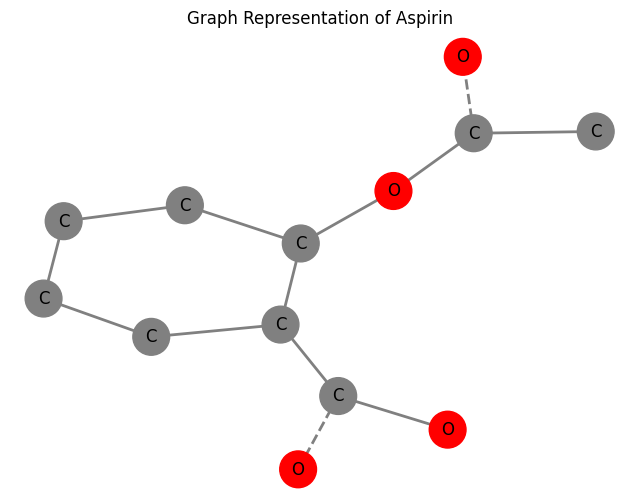

In [287]:

## --- Example molecule conversion ---
SMILES = 'CC(=O)OC1=CC=CC=C1C(=O)O'  # Acetylsalicylic acid (Aspirin)
g: nx.Graph = graph_from_smiles(SMILES)
    
# We can then create a visualization of the graph using matplotlib and networkx
# as well as the custom "draw_graph" function which we have introduced above 
# exactly for this purpose.
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
draw_graph(g, ax)
plt.title('Graph Representation of Aspirin')
plt.axis('off')
plt.show()

**Pytorch Geometric Graph Representation.** In the end, we want to use the graph structures as inputs to graph neural network models. In the `pytorch_geometric` library this requires the construction of a `Data` object to represent each of the graph structures. The function `data_from_graph` below therefore handles the conversion of `networkx.Graph` objects to `pytorch_geometric.Data` objects.

In the default case, a Data object requires knowledge about the following 3 attributes:

- `x`: a pytorch tensor of the shape $(V, N)$ where $V$ is the number of nodes in the graph and $N$ is the number of features each node is represented by.
- `edge_index`: a pytorch tensor of the shape $(2, E)$ where $E$ is the number of edges of the graph. An example column of this vector might be $(2, 1)$ which indicates that a *directed* edge exists from node with index 2 to node with index 1.
- `edge_attr`: A pytorch tensor of the shape $(E, M)$ where $E$ is again the number of edges and $M$ is the number of features per edge. 

**📝 Bidirectional Edges.** By default, pytorch geometric works with *directional* edges. This means that in the example edge $(2, 1)$ from above there exists a connection from node 2 to node 1 but *no* direction back from node 1 to node 2. This would imply that messages in the graph neural networks can only flow in one direction as well. In certain graph-related applications this principle of directionality is an important feature of the domain. For chemistry-related applications, however, it makes more sense to consider *undirectional* edges, where information can flow regardless of the direction. In `pytorch_geometric` this can be achieved by not only including the edges $(2, 1)$ but also including the edge $(1, 2)$ explicitly. 

In [288]:

def data_from_graph(graph: nx.Graph) -> Data:
    """
    Convert a NetworkX graph to a PyTorch Geometric Data object.
    
    IMPORTANT: This function creates BIDIRECTIONAL edges, which is required for 
    proper message passing in PyTorch Geometric GNNs. NetworkX undirected graphs 
    store each edge once, but PyG expects both (u,v) and (v,u) to be present.
    
    :param graph: A NetworkX Graph object with node and edge attributes.
    :returns: A PyTorch Geometric Data object.
    """
    node_attributes = np.array([
        data['node_attributes'].tolist() for _, data in graph.nodes(data=True)
    ])
    
    # Create BIDIRECTIONAL edges - PyTorch Geometric expects both directions
    # for undirected graphs to enable proper message passing
    # Practially this is done by just inserting each edge from the networkx graph 
    # into the torch edge list twice - once for each direction, where both share 
    # the same edge attributes.
    edge_indices = []
    edge_attributes = []
    for (u, v, data) in graph.edges(data=True):
        # Add edge in both directions
        edge_indices.append((u, v))
        edge_indices.append((v, u))
        # Same attributes for both directions (symmetric)
        edge_attributes.append(data['edge_attributes'].tolist())
        edge_attributes.append(data['edge_attributes'].tolist())
    
    edge_indices = np.array(edge_indices) if edge_indices else np.zeros((0, 2), dtype=np.int64)
    edge_attributes = np.array(edge_attributes) if edge_attributes else np.zeros((0, 0), dtype=np.float32)
    
    data = Data(
        x=torch.tensor(node_attributes, dtype=torch.float32),
        # NOTE: We transpose (.T) the edge index list here to have the shape 
        # (2, num_edges) as expected by the Pytorch Geometric Data class format!
        edge_index=torch.tensor(edge_indices.T, dtype=torch.long),
        # Contrary to the edge_index tensor, the edge_attr tensor has to be the 
        # shape (num_edges, num_edge_features).
        edge_attr=torch.tensor(edge_attributes, dtype=torch.float32),
    )
    
    # If the graph has a 'graph_labels' attribute, we can attach it to the data 
    # object as well.
    if graph.graph.get('graph_labels') is not None:
        data.y = torch.tensor(graph.graph['graph_labels'], dtype=torch.float32)
    
    return data
    
    
## --- Example conversion to PyG Data ---

data: Data = data_from_graph(g)
print('Graph Data Object')
print('=================')
print(data, '\n')
print(f'{data.x.size(0)} nodes with {data.x.size(1)} features each')
print(f'{data.edge_index.size(1)} edges (twice the number of bonds because bidirectional)')
print(f'with {data.edge_attr.size(1)} edge attributes each')
print()

Graph Data Object
Data(x=[13, 12], edge_index=[2, 26], edge_attr=[26, 6]) 

13 nodes with 12 features each
26 edges (twice the number of bonds because bidirectional)
with 6 edge attributes each



### Graph Neural Network Property Prediction

To implement the *Graph Neural Network (GNN)* model itself, we will do so using the popular [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) and further wrapping the model using [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/).

**Graph Neural Networks.** An *exhaustive* introduction of graph neural networks would exceed the scope of this tutorial series, but can be found in various online resources such as this [Gentle Introduction to Graph Neural Networks](https://distill.pub/2021/gnn-intro/) or the [Pytorch Geometric Documentation](https://pytorch-geometric.readthedocs.io/en/2.3.0/tutorial/create_gnn.html). Roughly speaking, graph neural networks address the important problem of working with *dynamic data structures*. Unlike in image processing - where all images already have or can be cropped to the exact same size - many other application domains need to work with data of vastly different sizes and formats. In chemistry, for instance, molecules come in all kinds of different shapes and sizes &mdash; from small drug-like molecules up to large protei structures. Trying to process instances with such different scales presents a considerable problem for machine learning models.

**Local Message Passing.** Graph neural networks solve this issue by moving the application of the neural network from the global graph-wide level to the *local* level. These networks dont operate directly on the graph itself, but are rather used to learn how to update the feautures of the individual *nodes* based on their locally neighboring nodes. In each "layer" of a GNN this is done such that each node receives "messages" from each of its direct neighbors containing information about their current state. Based on this aggregation of its neighbor states, a neural network is then used to update the state of the current node. After $L$ cycles of these local updates, the resulting representations of the individual nodes are compressed via an often simple aggregation function (e.g. the sum or average) and then further processed by neural networks to predict various graph-global properties.

**Pytorch Geometric.** PyG is a popular *framework* wich provides lots of useful utility functions, existing implementations and guidelines for the development of graph neural networks, specifically. To create a GNN model, one can create a custom subclass of the default `torch.nn.Module` and select message passing layers from a broad selection of pre-implemented choices. For this example, we'll use the [GINEConv](https://arxiv.org/abs/1810.00826) layer due to its capability of utilizing edge features. After defining the basic architecture &mdash; including the message passing layers, the aggregation function and the prediction network &mdash; one has to define the `forward(data: Data) -> torch.Tensor` method which implements the exact way in which the network's components are applied to a mapping from the original graph structure to the (singular) prediction of the desired property.


In [289]:
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import SumAggregation

# --- Torch Module ---
# The base torch module which implements the graph neural network itself.

class SimpleGNNModel(nn.Module):
    """
    Native PyTorch GNN model that outputs log probabilities via log_softmax.
    
    This is the core model architecture without any training logic. It can be
    used directly with explanation methods like GNNExplainer and PGExplainer.
    
    For binary classification, this model outputs 2 log probabilities (one per class).
    """
    
    def __init__(self, 
                 input_dim: int,
                 edge_dim: int,
                 hidden_units: int = 64,
                 edge_units: int = 64,
                 dense_units: list[int] = [64, 32],
                 output_dim: int = 2,
                 ) -> None:
        
        super().__init__()
        self.input_dim = input_dim
        self.edge_dim = edge_dim
        self.edge_units = edge_units
        self.hidden_units = hidden_units
        self.dense_units = dense_units
        self.output_dim = output_dim
        
        ## --- Define model architecture ---
        
        self.lay_embedd = nn.Linear(input_dim, hidden_units)
        self.lay_embedd_edge = nn.Linear(edge_dim, edge_units)
        
        ## --- graph convolutional layers ---
        
        self.lay_conv_1 = GINEConv(
            nn=nn.Sequential(
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.ReLU(),
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.LeakyReLU()
            ),
            edge_dim=edge_units,
        )
        self.lay_conv_2 = GINEConv(
            nn=nn.Sequential(
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.ReLU(),
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.LeakyReLU()
            ),
            edge_dim=edge_units,
        )
        self.lay_conv_3 = GINEConv(
            nn=nn.Sequential(
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.ReLU(),
                nn.Linear(hidden_units, hidden_units),
                nn.LayerNorm(hidden_units),
                nn.LeakyReLU()
            ),
            edge_dim=edge_units,
        )
        self.conv_layers = [
            self.lay_conv_1, 
            self.lay_conv_2, 
            self.lay_conv_3
        ]
            
        ## --- global pooling layer ---
        self.lay_pool = SumAggregation()
            
        ## --- dense layers ---
        _hidden = hidden_units
        self.dense_layers = nn.ModuleList()
        for units in dense_units:
            lay_dense = nn.Sequential(
                nn.Linear(_hidden, units),
                nn.LayerNorm(units),
                nn.ReLU()
            )
            self.dense_layers.append(lay_dense)
            _hidden = units
            
        self.lay_out = nn.Linear(_hidden, output_dim)
        
    def forward(
        self, 
        x, 
        edge_index, 
        edge_attr, 
        batch, 
        edge_weight=None
    ) -> torch.Tensor:
        """
        Forward pass that returns LOG PROBABILITIES (not raw logits).
        
        :returns: Tensor of shape (batch_size, num_classes) containing log probabilities
        """
        
        # Embedding the node and edge features
        edge_embedding = self.lay_embedd_edge(edge_attr)
        node_embedding = self.lay_embedd(x)
        
        # Graph convolution / message passing layers
        for lay_conv in self.conv_layers:
            node_embedding = lay_conv(
                x=node_embedding, 
                edge_index=edge_index,
                edge_attr=edge_embedding,
            )
            
        # Global sum pooling
        graph_embedding = self.lay_pool(node_embedding, batch)
        
        # Dense prediction layers
        output = graph_embedding
        for lay_dense in self.dense_layers:
            output = lay_dense(output)
            
        # Final linear layer produces raw logits
        logits = self.lay_out(output)
        
        # Apply log_softmax to get log probabilities
        log_probs = F.log_softmax(logits, dim=-1)
        
        return log_probs
    
    def copy(self) -> "SimpleGNNModel":
        """
        This method returns a new, copied instance of the graph neural network, with 
        the same functions and same parameters.
        
        :returns: A new instance of the SimpleGNNModel class
        """
        
        # Practically we can achieve this copy process by first instantiating a new 
        # "empty" model instance with the same parameters as the current model.
        # Then the "load_state_dict" functionality of the nn.Module base class can 
        # be used to populate all of the internal model weights with the model weights 
        # of the current model - effectively resulting in a copy.
        model = self.__class__(
            input_dim=self.input_dim,
            edge_dim=self.edge_dim,
            hidden_units=self.hidden_units,
            edge_units=self.edge_units,
            dense_units=self.dense_units,
            output_dim=self.output_dim
        )
        model.load_state_dict(self.state_dict())
        return model



<details style="border: 1.5px #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 The purpose of the <code>copy</code> method</summary>

You may have seen the <code>copy</code> method implemented for the <code>SimpleGNNModel</code> class above. Its purpose is to create an identical copy of the copy of the model, including the same methods and same parameters.

You'll also observe in the code following below that this copy method is used to provide a copy of the model for each of the explanation methods. So instead of applying all of the explanation methods on the same <em>instance</em> of the model, the explanations are generated based on <em>copies</em> of the same model.

The practical reason for doing these copy operations is to prevent <em>side effects</em>. In general, side effects refer to an often undesirable phenomenon when dealing with state-based objects. Some object instance might be passed on to various functions that perform operations based on this instance. Ideally, these functions would implement purely input-output behavior - only <em>reading</em> the state of the instance, performing computations and returning the result. Some functions, however, also need to, or accidentally, modify the state of the given object instances as well. Especially in cases where these state modifications are not explicitly documented, this can easily lead to complex errors further down the line - where it is assumed that the instances are in a certain state <em>A</em> but are really in state <em>B</em> because they have been silently modified previously.

In fact, side effects present a very real issue in the implementations of this tutorial notebook. Without using the copy operation, all of the explanation methods would be applied to the same instance of the model. The explanation functionality implemented in the <code>pytorch_geometric.explain</code> package internally relies on state-manipulation of the model, primarily in the form of <em>masking</em> certain edges during the message passing operations. The <code>GNNExplainer</code>, then, is first applied to the model, which modifies its internal state. These modifications then prevent the subsequent application of the <code>PGExplainer</code> to work properly - causing it not to learn properly.

Regardless of whether an actual problem has already manifest itself or not, keeping the possibility of side effects in mind and guarding against it - e.g. by using copies where possible - is generally a good practice to follow when developing complex processing pipelines. 

</details>

Defining the GNN model itself only completes half of the required work, however. Aside from the model, one also has to take care of defining the *training process*, including the choice of the optimizer, the various hyperparameters, the loss functions and the way in which the gradients of the loss function are used to update the model weights.

**Pytorch Lightning.** Although all of the above is possible in pytorch itself, much of the required code is often simply repeated between different projects. [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) is a library which simplifies much of the implementation effort into more organized structures. To make use of Lightning's implementation of model training, we need to wrap the previously defined GNN model in a `LightningModule` class which not only defines a `forward` method but also defines additional methods such as `training_step` and `configure_optimizers` regarding the training process itself.

In [290]:

class SimpleClassifier(pl.LightningModule):
    """
    PyTorch Lightning wrapper around SimpleGNNModel for training.
    
    This class handles training/validation logic, loss computation, metrics,
    and optimizer configuration. The actual model architecture is contained
    in the `model` attribute (a SimpleGNNModel instance).
    
    For explanation methods (GNNExplainer, PGExplainer), use `self.model` directly
    to access the native PyTorch module.
    """
    
    def __init__(self, 
                 input_dim: int,
                 edge_dim: int,
                 hidden_units: int = 64,
                 edge_units: int = 64,
                 dense_units: list[int] = [64, 32],
                 output_dim: int = 2,
                 learning_rate: float = 1e-4,
                 ) -> None:
        
        super().__init__()
        self.learning_rate = learning_rate
        self.save_hyperparameters()
        
        # Create the underlying native PyTorch model
        self.model = SimpleGNNModel(
            input_dim=input_dim,
            edge_dim=edge_dim,
            hidden_units=hidden_units,
            edge_units=edge_units,
            dense_units=dense_units,
            output_dim=output_dim,
        )
        
        # NLLLoss expects log probabilities as input and class indices as target
        self.criterion = nn.NLLLoss()
        # Multiclass accuracy metric
        self.metric = Accuracy(task='multiclass', num_classes=output_dim)
        
    def forward(
        self, 
        x, 
        edge_index, 
        edge_attr, 
        batch, 
        edge_weight=None
    ) -> torch.Tensor:
        """
        Forward pass delegated to the underlying model.
        
        :returns: Tensor of shape (batch_size, num_classes) containing log probabilities
        """
        return self.model(x, edge_index, edge_attr, batch, edge_weight)
    
    def training_step(self, batch: Data, batch_idx: int) -> torch.Tensor:
        """
        Training step using NLLLoss with log probabilities.
        """
        batch_size = torch.max(batch.batch) + 1
        
        # Forward pass returns log probabilities
        log_probs: torch.Tensor = self(
            batch.x, 
            batch.edge_index, 
            batch.edge_attr, 
            batch.batch
        )
        
        # NLLLoss expects class indices as target (long tensor)
        # batch.y is float [0.0, 1.0], convert to long class indices
        targets = batch.y.long()
        
        loss: torch.Tensor = self.criterion(log_probs, targets)
        
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True, batch_size=batch_size)
        
        return loss
    
    def validation_step(self, batch: Data, batch_idx: int) -> None:
        """
        Validation step computing accuracy from log probabilities.
        """
        log_probs: torch.Tensor = self(
            batch.x, 
            batch.edge_index, 
            batch.edge_attr, 
            batch.batch
        )
        
        # Get predicted class (argmax of log probs = argmax of probs)
        preds = log_probs.argmax(dim=-1)
        targets = batch.y.long()
        
        self.metric.update(preds, targets)
    
    def on_validation_epoch_end(self) -> None:
        self.log('val_metric', self.metric.compute(), prog_bar=True, on_step=False, on_epoch=True)
        self.metric.reset()
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), 
            lr=self.learning_rate, 
            weight_decay=1e-5
        )
        return optimizer
    
    def forward_graphs(self, 
                       graphs: list[nx.Graph], 
                       batch_size: int = 32
                       ) -> list[np.ndarray]:
        """
        Convenience method for batch inference on a list of graphs.
        Returns log probabilities for each graph.
        """
        with torch.no_grad():
            
            data_list: list[Data] = [data_from_graph(graph) for graph in graphs]
            loader = DataLoader(data_list, batch_size=batch_size, shuffle=False)
            
            results: list[np.ndarray] = []
            
            for batch in loader:
                log_probs = self(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                log_probs_np = log_probs.detach().cpu().numpy()
                
                for lp in log_probs_np:
                    results.append(lp)
                    
            return results

**Converting Dataset.** Before being able to start the model training, we need to convert the dataset into the suitable representation using the `graph_from_smiles` and `data_from_graph` functions.


In [291]:
# First we can use the `graph_from_smiles` function to convert the SMILES strings in the dataset into networkx graph 
# objects.
data_frame['graph'] = data_frame['smiles'].apply(graph_from_smiles)
# However, we also want to attach the target values (stored in the "Target" column of the data frame) to the graph objects 
# as this is needed for the conversion to the Data object format used by Pytorch Geometric.
for idx, row in data_frame.iterrows():
    row['graph'].graph['graph_labels'] = row['Activity']
    
data_frame.head()

,CAS_NO,Activity,smiles,graph
0,2475-33-4,0,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,820-75-7,1,N#C/N=C/C(=O)NCC(=O)NN,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)"
2,2435-76-9,1,N#C/N=C1/C=NC(=O)NC1=O,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)"
3,817-99-2,1,N#C/N=C/C(=O)NCC(N)=O,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)"
4,116539-70-9,1,CCCCN(CC(O)C1=C/C(=N\C#N)C(=O)C=C1)N=O,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


In [292]:
# --- train-test split ---
# Balanced train-test split: sample equal number of actives (Target==1) and inactives (Target==0) for the test set

# Find indices for actives and inactives
active_indices = data_frame.index[data_frame['Activity'] == 1].tolist()
inactive_indices = data_frame.index[data_frame['Activity'] == 0].tolist()

# Sample test indices for each class
test_active = random.sample(active_indices, k=50)
test_inactive = random.sample(inactive_indices, k=50)
test_indices = test_active + test_inactive

# Remaining indices for training
train_indices = list(set(range(len(data_frame))) - set(test_indices))

# --- creating Data objects ---
# Now we can create a list of `Data` objects from the `graph` column of the `data_frame` using the 
# `data_from_graph` function defined above.

data_list_train: list[Data] = [
    data_from_graph(data_frame.iloc[index]['graph'])
    for index in train_indices
]
data_list_test: list[Data] = [
    data_from_graph(data_frame.iloc[index]['graph'])
    for index in test_indices
]

# --- creating dataloaders ---

# Finally, we can create the `DataLoader` objects from both of these subset instances. 
# Since these data loaders automatically handle the shuffling and batching of the data during training, 
# they need to receive the batch size as a constructor argument. The `num_workers` argument specifies 
# how many subprocesses to use for data loading. Together with a reasonable `prefetch_factor`, this 
# ensures that the data is loaded efficiently during training - preventing performance bottlenecks.
loader_train = DataLoader(data_list_train, batch_size=64, shuffle=True, num_workers=4, prefetch_factor=3, drop_last=True)
loader_test = DataLoader(data_list_test, batch_size=32, shuffle=False)

<details style="border: 1.5px #536CCE; border-radius: 3px; padding: 10px; background-color:#EFF2FD; color: black; font-size: 0.9em;">
<summary style="cursor: pointer; font-weight: bold; color: #536CCE;">📔 PytorchGeometric Dataloaders and Graph Batching.</summary>

In <code>pytorch_geometric</code> the graphs are represented as individual <code>Data</code> objects and a dataset of molecules, for instance, can be seen as a list of such Data object. However, to train a PyG graph neural network one doesn't use raw lists of data objects but rather special <code>DataLoader</code> objects that are constructed from the former.

These <code>DataLoader</code> instances solve the hard problem of <em>graph batching</em>. Batching is a method that is employed to improve the computational efficiency of neural network training and describes the process of paralellizing the forward pass, loss calculation and subsequent model update across multiple samples, instead of having to process each sample individually. For data structures of fixed size &mdash; like in image processing &mdash; this simply boils down to introducing another dimension of the input tensor to contain these batched samples. This batched tensor can be passed through the model with minimal additional effort.

Since graph structures can have vastly different sizes, they cannot be easily accumulated into a fixed size tensor. Pytorch Geometric addresses this issue by <em>concatenating</em> the information of the individual samples instead of distributing it across a separate dimension of the tensor. However, without the clear seperation provided by the dimension, additional efforts needs to be invested to be able to correctly identify which values belong to which graph. For this purpose, an additional <code>data.batch</code> vector is added to the Data object which contains as many elements as there are nodes in the combined graph and which uniquely identify the graph that "owns" the corresponding node via integer indices.

This graph batching process including the concatenation of multiple graph structures and the creation of the <code>batch</code> index vector is handled by the <code>DataLoader</code> objects.

On the implementation side all of these complexities are neatly hidden from the user and the DataLoader objects provide an iterator interface, which allows to directly iterate over them with a "for" loop. Each iteration of this for loop yields such a graph batch, where all of the features are concatenated and assigned by batch indices.

</details>

**Instantiating the Model.** After defining the model architecture and converting the dataset, we can now instantiate the model itself in preparation of the training. To calculate the number of model weights, the model class requires information about the number of node and edge features present in the given dataset. We obtain these directly from an example element of the dataset.

In [293]:
example_data: Data = data_list_train[0]

num_node_features: int = example_data.x.shape[1]
num_edge_features: int = example_data.edge_attr.shape[1]

model = SimpleClassifier(
    input_dim=num_node_features,
    edge_dim=num_edge_features,
    hidden_units=128,
    dense_units=[128, 64, 32],
    output_dim=2,  # 2 classes for binary classification with log_softmax
)

print('GNN Model')
print('=========')
print(f'{num_node_features} input node features')
print(f'{num_edge_features} input edge features')
print(f'{model.model.__class__.__name__} model with {model.__class__.__name__} Lightning wrapper')
print(f'{sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters')

GNN Model
12 input node features
6 input edge features
SimpleGNNModel model with SimpleClassifier Lightning wrapper
155,042 trainable parameters


**Model Training.** The instantiated model can then be trained using a Lightning `Trainer` object.

In [294]:
# PytorchLighting allows to use so called "Callback" instances during the model 
# training which make it possible to execute custom code during specific stages of 
# the training process. The "PrintLossCallback" which is imported here executes at the 
# end of each training epoch to print the current loss value at each n-th epoch to 
# the console so that the user can track the training progress in real time.
from xai_chem_review.utils import PrintLossCallback

trainer = pl.Trainer(
    max_epochs=100,
    # The "accelerator" is the device on which the training should happen. Its possible 
    # to either define CPU or GPU here. The setting "auto" will select the 
    # best one which is availbe automatically.
    accelerator='auto',
    callbacks=[
        PrintLossCallback()
    ]
)

# The fit method actually executes the training and due to the PrintLossCallback
# will periodically print the progress of the loss value.
trainer.fit(
    model=model,
    train_dataloaders=loader_train,
    val_dataloaders=loader_test,
)

# Pytorch models can be in "training" mode or in "evalulation" (eval) mode. This mode 
# determines the behavior of a few selected layer types that are commonly used in 
# neural networks such as normalization or dropout layers.
# After completing the training, it is important to set the model in to evaluation 
# mode to ensure proper behavior.
model.eval()

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /media/ssd2/Programming/xai_chem_review/.venv/lib/py ...
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ SimpleGNNModel     │  155 K │ train │     0 │
│ 1 │ criterion │ NLLLoss            │      0 │ train │     0 │
│ 2 │ metric    │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 155 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 155 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 50                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/dat
a_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.

...

Epoch 85 | train_loss: 0.2127

Epoch 90 | train_loss: 0.2025

Epoch 95 | train_loss: 0.2044

`Trainer.fit` stopped: `max_epochs=100` reached.


SimpleClassifier(
  (model): SimpleGNNModel(
    (lay_embedd): Linear(in_features=12, out_features=128, bias=True)
    (lay_embedd_edge): Linear(in_features=6, out_features=64, bias=True)
    (lay_conv_1): GINEConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (5): LeakyReLU(negative_slope=0.01)
    ))
    (lay_conv_2): GINEConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (5): LeakyReLU(negative_slope=0.01)
    ))
    (lay_conv_3): GINEConv(nn=Sequential(
      (0): Linear(in_features=128, o

**Model Evaluation.** Before using the model to generate explanations, we should evaluate its predictive performance on the test set. This ensures that we are explaining a model that has learned meaningful patterns from the data at all. The model at hand is a *classification* model which means that we can calculate typical *classification* metrcis such as the accuracy, precision and recall scores. Most metrics can easily be calculated by calling the corresponding functions from the `scikit-learn` library.

In [295]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# --- Evaluate model on test set ---

model.eval()

# Collect predictions and ground truth labels
y_true = []
y_pred_proba = []  # Probability of positive class (class 1)

with torch.no_grad():
    for batch in loader_test:
        
        batch = batch.to(model.device)
        # Model now returns log probabilities of shape (batch_size, 2)
        log_probs = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        # Convert log probs to probs and get probability of positive class (index 1)
        probs = torch.exp(log_probs)
        probs_positive = probs[:, 1].cpu().numpy()
        
        y_pred_proba.extend(probs_positive)
        y_true.extend(batch.y.cpu().numpy().flatten())

y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_proba)

print('Model Evaluation on Test Set:')
print(f'  Accuracy:  {accuracy:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1 Score:  {f1:.4f}')
print(f'  ROC-AUC:   {roc_auc:.4f}')

Model Evaluation on Test Set:
  Accuracy:  0.7900
  Precision: 0.8085
  Recall:    0.7600
  F1 Score:  0.7835
  ROC-AUC:   0.8540


**🔍 Mutagenicity Prediction Results.** At this point, the model should achieve a prediction accuracy of around 80% (between 75 and 85%) &mdash; which is most likely around the noise ceiling of this particular dataset. The models can show quite large deviations partially due to the random variations of the train-test-splitting but also due model initializations and inoptimized hyperparameters. However, if the prediction accuracy is notably below 70% it is advisable to rerun the model training cells &mdash; potentially with a higher number of training epochs.

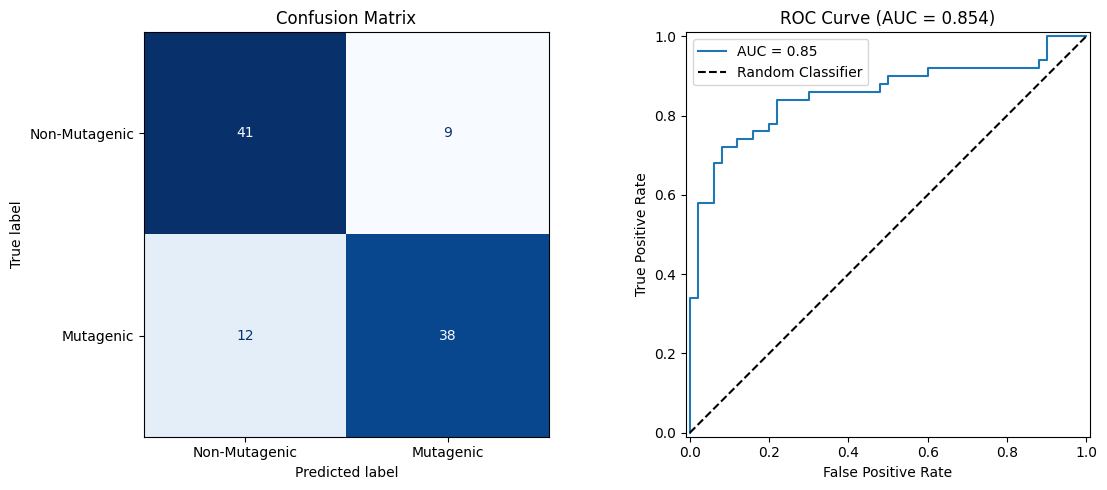

In [296]:
# --- Visualize evaluation results ---

from sklearn.metrics import roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Mutagenic', 'Mutagenic'])
disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
disp_roc = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
disp_roc.plot(ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_title(f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 2.2** $\cdot$ The GNN architecture choices significantly impact both prediction accuracy and the explanations that can be derived from the model. The current model uses 3 GINEConv layers with 128 hidden units.

Try modifying the model architecture:
1. Change `hidden_units` to 64 or 256
2. Modify `dense_units` to use fewer or more layers (e.g., `[64, 32]` vs `[128, 128, 64, 32]`)

After retraining, compare: (1) the test set accuracy, and (2) whether the explanations from GNNExplainer highlight similar substructures. Do deeper/wider models produce more or less interpretable explanations?

**Hint:** You may want to note down or save the results so you can compare them later.
</div>

**Generating Graph Explanations with PyG.** To generate explanations in the `pytorch_geometric.explain` framework, we firstly need to set up a generic `Explainer` class. In this class, one needs to specify the general *kind* of explanation to be generated, including the following parameters:

- `explanation_type`: distinguishes between "model" and "phenomenon", which influence with respect to which target property the explanations are being optimized. In the case of *"model"*, the explanations are being optimized to explain the model's prediction &mdash; even if they are incorrect.
- `node_mask_type`: Determines how the node explanations will look like. In the case of *"object"* nodes are masked as one unit &mdash; a node can either be marked as important, or not. Alternatives would allow only for individual features within the nodes to be masked and consequently be explained.
- `edge_mask_Type`: Determines how the edge explanations will look like in the same manner.
- `model_config`: This parameter provides the required information to the explainer of how the model works, in the first place.
    - `mode`: This defines what the purpose of the model was, which could either be classification (as in this example) of discrete classes or it may also be regression of continuous values.
    - `task_level`: Defines at which "level of granularity" the property is being predicted. The *"graph"* option, as given in this example, specifies that the target properties are predicted on the level of the graph as a whole. Alternatively, there are other kinds of graph neural networks to make predictions for the individual *nodes* or *edges* of a graph structure.

**Obtaining Explanations.** After properly setting up the `Explainer` class with all of the relevant information about the model as well as the options of what kinds of explanations are expected, one can generate an explanation by calling the explainer instance with the graph(s) of interest in the format of a PyG graph batch.

**📝 Creating single-graph batches with `DataLoader`.** The above cell below demonstrates how to prepare a single-graph batch. The reason why this is necessary is that the creation of an `Explanation` with the the `GNNExplainer` requires a batched `Data` object rather than an individual graph. Consequently, we need to batch all inputs &mdash; even if it is only a single graph. As seen above, this is done by constructing the individual `Data` object, handing it in a single-element list to the DataLoader and then calling the `next` function on the DataLoader iterator.

```python
data: Data = Data(...)
loader = DataLoader([data], batch_size=1)
batch: Data = next(iter(loader))
```

In [297]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer
from torch_geometric.explain.config import ModelConfig, ThresholdConfig

# Use the native torch module (model.model) for the explainer
# This avoids Lightning-specific wrappers that can interfere with explanation methods
explainer = Explainer(
    model=model.model.copy(),
    algorithm=GNNExplainer(epochs=300, lr=0.01, edge_size=5e-3, edge_ent=1.0),
    explanation_type='phenomenon',
    node_mask_type='object',
    edge_mask_type='object',
    model_config=ModelConfig(
        mode='multiclass_classification',
        task_level='graph',
        return_type='log_probs',
    ),
)

In [298]:
# SMILES representation of the molecule to explain.
SMILES: str = '[O-][N+](=O)c1cc(CCO)ccc1'

# We first convert the SMILES into the networkx Graph intermediate representation
graph: nx.Graph = graph_from_smiles(SMILES)
graph.graph['graph_labels'] = [1]
# This can then be converted in the pytorch_geometric Data representation of 
# a graph structure.
data: Data = data_from_graph(graph)
# However, the explainer requires a *batched* graph to create the explanation
# We therefore use the DataLoader utility to turn the single-graph Data instance 
# into a batched Data instance.
loader: DataLoader = DataLoader([data], batch_size=1, shuffle=False)
batch: Data = next(iter(loader))

# The explanation can be created by calling the explainer instance with 
# the input sample of interest.
explanation = explainer(
    x=batch.x,
    edge_index=batch.edge_index,
    edge_attr=batch.edge_attr,
    batch=batch.batch,
    # Target should be class index (long tensor) for multiclass_classification
    target=batch.y.long(),
    index=0
)

print('Graph Explanation')
print('=================')
print(explanation)

Graph Explanation
Explanation(node_mask=[12, 1], edge_mask=[24], target=[1], index=[1], x=[12, 12], edge_index=[2, 24], edge_attr=[24, 6], batch=[12])


**Visualization of Explanation Masks.** Upon calling the `Explainer` on the given graph, it returns an `Explanation` object containing the mask (explanation) values for all of the nodes and edges. However, to become useful to a human observer, this explanation will have to be *visualized* in some manner. The code below implements this visualization in two steps:

- *Adding the explanation to the `nx.Graph`.* This first step adds the information about the explanations to the networkx graph object representing the graph in question by adding an additional attribute `node_explanation` to each node and an additional value `edge_explanation` to each edge. This step is to simplify the subsequent visualization so that we only have to provide it the graph object.
- *Drawing the visualization into a plot.* The `draw_explanation` function then takes the graph, along with the position matrix to visualize the individual explanation mask values. This is done by painting colored sections behind the corresponding graph elements (circles for the nodes, thicker lines for the edges), where the transparency of the elements encodes the strength of the explanation: More colorful highlights indicate more important elements.

In [299]:
import matplotlib.colors as mcolors

# --- Adding Explanation to Graph ---

def graph_add_explanation(
    graph: nx.Graph,
    explanation,
) -> nx.Graph:
    """
    Attaches the information given by the `explanation` to the given `graph` 
    instance into the additional node/edge properties "node_explanation" and 
    "edge_explanation".
    
    :param graph: The networkx Graph instance to represent the graph
    :param explanation: The PyG explanation for that graph.
    
    :returns: The updated graph object
    """

    for node_idx, node_mask in enumerate(explanation.node_mask):
        graph.nodes[node_idx]['node_explanation'] = node_mask.detach().cpu().numpy()

    # For edge masks, average the masks from both directions (u,v) and (v,u)
    # since we have bidirectional edges but NetworkX stores edges once
    edge_masks_dict = {}
    for (u, v), edge_mask in zip(explanation.edge_index.t(), explanation.edge_mask):
        u_idx, v_idx = u.item(), v.item()
        key = (min(u_idx, v_idx), max(u_idx, v_idx))
        if key not in edge_masks_dict:
            edge_masks_dict[key] = []
        edge_masks_dict[key].append(edge_mask.detach().cpu().item())

    for (u, v), masks in edge_masks_dict.items():
        avg_mask = np.mean(masks)
        if graph.has_edge(u, v):
            graph.edges[(u, v)]['edge_explanation'] = avg_mask
        elif graph.has_edge(v, u):
            graph.edges[(v, u)]['edge_explanation'] = avg_mask

    return graph

# --- Explanation Visualization ---

def draw_explanation(
    graph: nx.Graph, 
    pos: dict, 
    ax: plt.Axes,
    node_key: str = "node_explanation",
    edge_key: str = "edge_explanation",
    diverging: bool = False,
    positive_color: str = "lightgreen",
    negative_color: str = "lightcoral",
) -> None:
    """
    Draws the explanation on the graph visualization.
    
    :param graph: The networkx graph with explanation attributes.
    :param pos: Dictionary of node positions.
    :param ax: The matplotlib axes to draw on.
    :param node_key: The key used to retrieve node explanation values from the graph.
        Default is "node_explanation".
    :param edge_key: The key used to retrieve edge explanation values from the graph.
        Default is "edge_explanation".
    :param diverging: If True, use diverging color scheme (green for positive, red for negative).
                      If False, use single color scheme (green for high values).
    :param positive_color: Color for positive/high importance values.
    :param negative_color: Color for negative importance values (only used if diverging=True).
    """
    white = np.array([1.0, 1.0, 1.0])
    pos_color = np.array(mcolors.to_rgb(positive_color))
    neg_color = np.array(mcolors.to_rgb(negative_color))
    
    for node, data in graph.nodes(data=True):
        
        if node_key in data:
            explanation_value = float(data[node_key])
            
            if diverging:
                # Diverging color scheme: negative -> red, zero -> white, positive -> green
                if explanation_value >= 0:
                    scaler = np.clip(explanation_value, 0.0, 1.0)
                    color = scaler * pos_color + (1 - scaler) * white
                else:
                    scaler = np.clip(-explanation_value, 0.0, 1.0)
                    color = scaler * neg_color + (1 - scaler) * white
            else:
                # Single color scheme: low -> white, high -> green
                scaler = np.clip(explanation_value, 0.0, 1.0)
                color = scaler * pos_color + (1 - scaler) * white
            
            ax.scatter(
                pos[node][0], pos[node][1],
                s=1500, color=[color],
                zorder=-10
            )
            
    for u, v, data in graph.edges(data=True):
        
        if edge_key in data:
            explanation_value = float(data[edge_key])
            
            if diverging:
                if explanation_value >= 0:
                    scaler = np.clip(explanation_value, 0.0, 1.0)
                    color = scaler * pos_color + (1 - scaler) * white
                else:
                    scaler = np.clip(-explanation_value, 0.0, 1.0)
                    color = scaler * neg_color + (1 - scaler) * white
            else:
                scaler = np.clip(explanation_value, 0.0, 1.0)
                color = scaler * pos_color + (1 - scaler) * white
            
            ax.plot(
                [pos[u][0], pos[v][0]], 
                [pos[u][1], pos[v][1]],
                color=color, 
                linewidth=15, 
                zorder=-20,
            )


/tmp/ipykernel_4116208/2588063129.py:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  explanation_value = float(data[node_key])


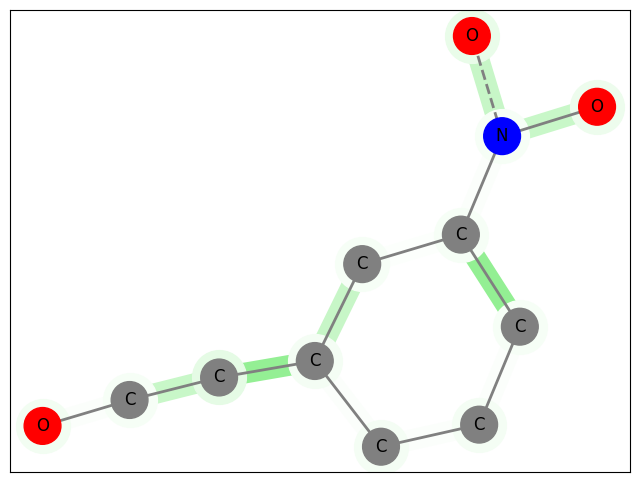

In [300]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# First we draw the graph itself onto the plot. This also provides the 
# vector of node positions within the plots coordinate system.
pos = draw_graph(graph, ax)

# Then the explanations are added to the background - behind the graph's
# nodes and edges.
graph_add_explanation(graph, explanation)
draw_explanation(graph, pos, ax)

## **2.3** $\cdot$ 📚 *Parameterized Graph Explainer* (`PGExplainer`)

The second structure-attribution method is the *Parameterized Explainer for Graph Neural Networks* (PGExplainer), proposed by [Luo *et al.*](https://arxiv.org/abs/2011.04573) in 2020. Unlike GNNExplainer which optimizes a mask for each individual graph, PGExplainer trains a neural network (an MLP) that learns to predict edge importance across the entire dataset.

**Core Methodology.** PGExplainer works by:
1. Extracting node embeddings from intermediate layers of the GNN model
2. For each edge, concatenating the embeddings of its source and target nodes
3. Passing these concatenated embeddings through an MLP to predict edge importance
4. Training this MLP on multiple graphs so it learns general patterns of what makes edges important

**Key Difference from GNNExplainer.** While GNNExplainer optimizes a mask *per graph* (making it slow but instance-specific), PGExplainer trains *once* on the dataset and can then quickly explain new graphs. This makes PGExplainer more suitable for production use cases where explanations need to be generated rapidly. However, this also means that it is more difficult to set up the PGExplainer explanations, since we now also have to train the explainer. The cell below shows an example implementation of that training process.

In [ ]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import PGExplainer
from torch_geometric.explain.config import ModelConfig, ThresholdConfig
from torch_geometric.utils import get_embeddings, scatter

EPOCHS = 50

# Use the native torch module for the explainer.
# Also: We'll use a copy of the original model, as with the previous explainer, to 
# hopefully prohibit side effects from influencing the result.
gnn_model = model.model.copy()
gnn_model.eval()

pg_explainer = Explainer(
    model=gnn_model,
    algorithm=PGExplainer(
        epochs=EPOCHS, 
        lr=0.003, 
        edge_size=1e-4, 
        edge_ent=0.0,
        #edge_size=0.0,
        #edge_ent=0.0,
        bias=0.01,
    ),
    explanation_type='phenomenon',
    node_mask_type=None,
    edge_mask_type='object',
    model_config=ModelConfig(
        mode='multiclass_classification',
        task_level='graph',
        return_type='log_probs',
    ),
)

# Move the explainer's MLP to the same device as the model
device = next(gnn_model.parameters()).device
pg_explainer.algorithm = pg_explainer.algorithm.to(device)

# Create a dataloader for training the explainer, here we can re-use the 
# training data list from before.
pg_train_loader = DataLoader(data_list_train, batch_size=64, shuffle=True)

print('Training PGExplainer...')
print('=======================')

for epoch in range(EPOCHS):
    
    losses = []
    all_logits = []
    all_masks = []
    
    for data in pg_train_loader:
        
        data = data.to(device)
        
        # We simply have to pass all the relevant information to this 
        # "train" method that is provided by the PGExplainer instance.
        loss = pg_explainer.algorithm.train(
            epoch=epoch,
            model=gnn_model,
            x=data.x,
            edge_index=data.edge_index,
            edge_attr=data.edge_attr,
            batch=data.batch,
            target=data.y.long(),
        )
        
        losses.append(loss)
        
    # --- start logging ---------------------------------
    # The following code is for logging purposes and to observe the training progress 
    # of the PGExplainer. This code is not *required* for the explanations but will 
    # provide some valuable insight into how the training is progressing.
    
        with torch.no_grad():
            
            # "get_embeddings" is a utility function that is provided by pytorch geometric 
            # which can return the intermediate node embeddings for a given GNN model and 
            # an input graph batch. The method will return a list of node embedding tensor, 
            # one tensor for each message passing layer contained in the model.
            zs: list[torch.Tensor] = get_embeddings(
                gnn_model, 
                x=data.x, 
                edge_index=data.edge_index, 
                edge_attr=data.edge_attr,
                batch=data.batch,
            )
            # For the PGExplainer we are only interested in the last layer embeddings 
            # in particular, which are the ones right before the aggregation
            z: torch.Tensor = zs[-1]
                
            # This internal "_get_inputs" function transforms the last layer embeddings 
            # into the actual input tensors for the explanation-predictio MLP that is 
            # at the core of the PGExplainer and which is currently being trained 
            # by this loop. 
            inputs = pg_explainer.algorithm._get_inputs(z, data.edge_index, None)
            logits = pg_explainer.algorithm.mlp(inputs).view(-1)
            
            # We log the resulting explanation masks so that we can print summary statistics 
            # for them below.
            all_logits.append(logits.cpu())
            all_masks.append(logits.sigmoid().cpu())
    
    # log the progress every 5th epoch
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        
        # Print explainer loss progression.
        print(f'Epoch {epoch:2d}:')
        print(f'  Loss: {np.mean(losses):.4f}')
        
        # Print explainer mask statistics.
        all_logits_cat = torch.cat(all_logits)
        all_masks_cat = torch.cat(all_masks)
        print(f'  Logits - mean: {all_logits_cat.mean():.3f}, std: {all_logits_cat.std():.3f}, '
              f'min: {all_logits_cat.min():.3f}, max: {all_logits_cat.max():.3f}')
        print(f'  Masks  - mean: {all_masks_cat.mean():.3f}, std: {all_masks_cat.std():.3f}, '
              f'min: {all_masks_cat.min():.3f}, max: {all_masks_cat.max():.3f}')
        print()
        
        # Check internal MLP gradients.
        for name, param in pg_explainer.algorithm.mlp.named_parameters():
            if param.grad is not None:
                print(f"{name}: grad_norm = {param.grad.norm():.6f}")
            else:
                print(f"{name}: NO GRADIENT")
                
        print()
                
    # --- end logging ----------------------------------

Training PGExplainer...
Epoch  0:
  Loss: 1.2243
  Logits - mean: -5.155, std: 7.703, min: -37.736, max: 10.094
  Masks  - mean: 0.239, std: 0.276, min: 0.000, max: 1.000

0.weight: grad_norm = 0.207483
0.bias: grad_norm = 0.021327
2.weight: grad_norm = 0.548622
2.bias: grad_norm = 0.020840

Epoch  5:
  Loss: 0.7587
  Logits - mean: -20.499, std: 8.552, min: -42.041, max: 25.881
  Masks  - mean: 0.025, std: 0.149, min: 0.000, max: 1.000

0.weight: grad_norm = 0.325873
0.bias: grad_norm = 0.035246
2.weight: grad_norm = 0.509770
2.bias: grad_norm = 0.028913

Epoch 10:
  Loss: 0.6960
  Logits - mean: -20.667, std: 9.616, min: -46.622, max: 32.073
  Masks  - mean: 0.027, std: 0.153, min: 0.000, max: 1.000

0.weight: grad_norm = 0.544462
0.bias: grad_norm = 0.064048
2.weight: grad_norm = 0.597726
2.bias: grad_norm = 0.038241

Epoch 15:
  Loss: 0.6663
  Logits - mean: -20.015, std: 9.726, min: -50.380, max: 40.961
  Masks  - mean: 0.029, std: 0.154, min: 0.000, max: 1.000

0.weight: grad_nor

**Generating Explanations with PGExplainer.** Now that the `PGExplainer` is trained, it can be used to generate explanations for novel input samples &mdash; in this case molecules. This is one possible advantage of PGExplainer over GNNExplainer &mdash; although it has to be initially trained for a longer time initially, it is much faster in generating the individual explanations afterwards. The explanations can be generated simply by calling the `PGExplainer` object instance with the relevant information about the graph `Data` instance in question.

In [302]:
# --- Generate PGExplainer explanation for a test molecule ---

SMILES = '[O-][N+](=O)c1cc(CCO)ccc1'

graph = graph_from_smiles(SMILES)
graph.graph['graph_labels'] = [1]
data = data_from_graph(graph)
loader = DataLoader([data], batch_size=1, shuffle=False)
batch = next(iter(loader))
batch = batch.to(model.device)

explanation = pg_explainer(
    x=batch.x,
    edge_index=batch.edge_index,
    edge_attr=batch.edge_attr,
    batch=batch.batch,
    # Target should be class index (long tensor) for multiclass_classification
    target=batch.y.long(),
)

print('PGExplainer Explanation:')
print(f'  Edge mask shape: {explanation.edge_mask.shape}')
print(f'  Edge mask min: {explanation.edge_mask.min():.4f}')
print(f'  Edge mask max: {explanation.edge_mask.max():.4f}')
print(f'  Edge mask mean: {explanation.edge_mask.mean():.4f}')

# --- Update graph with edge explanations ---
# Note: PGExplainer only provides edge masks, not node masks
# Since we have bidirectional edges, we need to average the masks for (u,v) and (v,u)

# Collect masks for each undirected edge (use canonical ordering as key)
edge_masks_dict = {}
for (u, v), edge_mask in zip(explanation.edge_index.t(), explanation.edge_mask):
    u_idx, v_idx = u.item(), v.item()
    # Use canonical ordering (smaller index first) as key for undirected edge
    key = (min(u_idx, v_idx), max(u_idx, v_idx))
    if key not in edge_masks_dict:
        edge_masks_dict[key] = []
    edge_masks_dict[key].append(edge_mask.detach().cpu().item())

# Average masks from both directions and assign to graph edges
for (u, v), masks in edge_masks_dict.items():
    avg_mask = np.mean(masks)
    # NetworkX stores undirected edges once - check both orderings
    if graph.has_edge(u, v):
        graph.edges[(u, v)]['edge_explanation'] = avg_mask
    elif graph.has_edge(v, u):
        graph.edges[(v, u)]['edge_explanation'] = avg_mask

print(f'\nAssigned edge explanations to {len(edge_masks_dict)} undirected edges')
print(f'  (averaged from {explanation.edge_mask.shape[0]} directed edge masks)')

PGExplainer Explanation:
  Edge mask shape: torch.Size([24])
  Edge mask min: 0.0000
  Edge mask max: 0.0012
  Edge mask mean: 0.0001

Assigned edge explanations to 12 undirected edges
  (averaged from 24 directed edge masks)


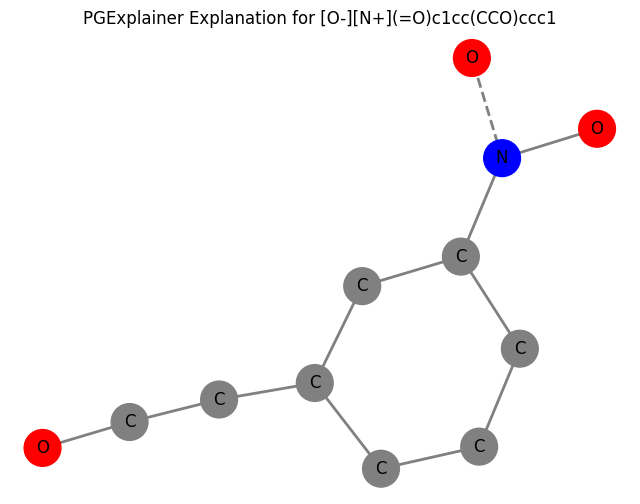

In [303]:
# --- Visualize PGExplainer explanation ---

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

pos = draw_graph(graph, ax)
draw_explanation(graph, pos, ax)

plt.title(f'PGExplainer Explanation for {SMILES}')
plt.axis('off')
plt.show()

**Node and Edge Explanations.** Comparing the explanation of `PGExplainer` with the previous one generated by `GNNExplainer`, one major difference is the lack of node explanations. Different explanation methods may provide only node attributions, only edge attributions, or both. To enable consistent visualization and comparison across methods, it is often useful to *cast* explanations from one type to the other. The `cast_explanations` function below achieves this by aggregating incident node values to derive edge explanations, or conversely, aggregating adjacent edge values to derive node explanations. Using such a utility function ensures that both node and edge importance can be visualized regardless of which attribution type the original method provides.

In [304]:
def cast_explanations(
    g: nx.Graph,
    node_key: str = "node_explanation",
    edge_key: str = "edge_explanation",
    aggregation: str = 'mean',
) -> nx.Graph:
    """
    Casts explanation attributes between nodes and edges of a graph.
    
    If the graph has only node explanations (under `node_key`), this function computes 
    edge explanations by aggregating the explanation values of incident nodes for each 
    edge. Conversely, if the graph has only edge explanations (under `edge_key`), it 
    computes node explanations by aggregating the explanation values of all adjacent 
    edges for each node.
    
    If the graph has both node and edge explanations, or neither, the graph is returned
    unchanged.
    
    :param g: A networkx Graph object that may contain explanation attributes 
        on its nodes and/or edges.
    :param node_key: The key used to store/retrieve node explanation values.
        Default is "node_explanation".
    :param edge_key: The key used to store/retrieve edge explanation values.
        Default is "edge_explanation".
    :param aggregation: The aggregation method to use when combining explanation values.
        Supported values are 'mean', 'max', 'min', and 'sum'. Default is 'mean'.
        
    :returns: The same graph object with potentially added explanation attributes.
        The graph is modified in-place.
    """
    
    # Dictionary mapping aggregation names to numpy functions.
    # This provides a simple way to select the aggregation method without
    # needing external helper functions.
    aggregation_functions = {
        'mean': np.mean,
        'max': np.max,
        'min': np.min,
        'sum': np.sum,
    }
    
    if aggregation not in aggregation_functions:
        raise ValueError(
            f"Unknown aggregation method: '{aggregation}'. "
            f"Supported methods are: {list(aggregation_functions.keys())}"
        )
    
    agg_fn = aggregation_functions[aggregation]
    
    # --- Check which explanation types are present ---
    # We check the first node/edge to determine if explanations exist.
    # We assume that if one node/edge has explanations, all of them do.
    
    has_node_explanations = False
    has_edge_explanations = False
    
    # Check for node explanations by inspecting the first node
    if len(g.nodes()) > 0:
        first_node_data = next(iter(g.nodes(data=True)))[1]
        has_node_explanations = node_key in first_node_data
    
    # Check for edge explanations by inspecting the first edge
    if len(g.edges()) > 0:
        first_edge_data = next(iter(g.edges(data=True)))[2]
        has_edge_explanations = edge_key in first_edge_data
    
    # --- Handle the different cases ---
    # If both or neither explanation types are present, return unchanged
    
    if has_node_explanations == has_edge_explanations:
        # Either both are True (has both) or both are False (has neither)
        return g
    
    if has_node_explanations and not has_edge_explanations:
        # Cast node explanations to edge explanations.
        # For each edge, aggregate the explanation values of its two incident nodes.
        
        for (u, v) in g.edges():
            node_u_explanation = g.nodes[u][node_key]
            node_v_explanation = g.nodes[v][node_key]
            
            # Aggregate the two node values to get the edge explanation
            edge_explanation = agg_fn([node_u_explanation, node_v_explanation])
            g.edges[(u, v)][edge_key] = float(edge_explanation)
    
    elif has_edge_explanations and not has_node_explanations:
        # Cast edge explanations to node explanations.
        # For each node, aggregate the explanation values of all adjacent edges.
        
        for node in g.nodes():
            # Collect explanation values from all edges connected to this node
            adjacent_edge_explanations = []
            
            for neighbor in g.neighbors(node):
                # NetworkX stores undirected edges once, so we need to check
                # which ordering exists in the graph
                if g.has_edge(node, neighbor):
                    edge_exp = g.edges[(node, neighbor)][edge_key]
                else:
                    edge_exp = g.edges[(neighbor, node)][edge_key]
                    
                adjacent_edge_explanations.append(edge_exp)
            
            # Aggregate the adjacent edge values to get the node explanation
            if len(adjacent_edge_explanations) > 0:
                node_explanation = agg_fn(adjacent_edge_explanations)
            else:
                # Isolated node with no adjacent edges - assign zero
                node_explanation = 0.0
                
            g.nodes[node][node_key] = float(node_explanation)
    
    return g

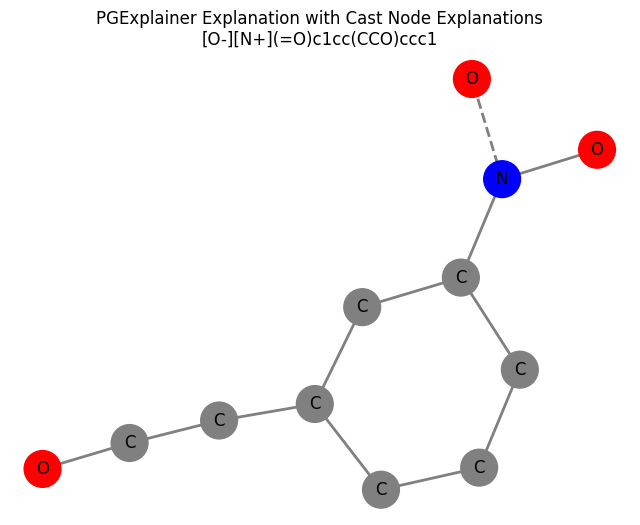

In [305]:
# --- Visualize PGExplainer explanation with cast node explanations ---
# The PGExplainer only provides edge explanations. We can use cast_explanations
# to derive node explanations from the edges, allowing for a more complete visualization.

# Cast the edge explanations to node explanations
cast_explanations(graph, aggregation='mean')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

pos = draw_graph(graph, ax)
draw_explanation(graph, pos, ax)

plt.title(f'PGExplainer Explanation with Cast Node Explanations\n{SMILES}')
plt.axis('off')
plt.show()

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 2.3** $\cdot$ The explanations produced by <code>PGExplainer</code> are &mdash; like many other explanations methods &mdash; sensitive to hyperparameter choices. In the case of <code>PGExplainer</code> that primarily includes the strength of the sparsity regularization <code>edge_size</code> and the edge entropy regularization <code>edge_ent</code>. Changing those parameters can lead to substantially different explanation results.

As briefly introduced above, the strength of the edge sparsity regularization controls how many edges shall be included as part of an explanation. This means the higher this value the less edges will be included in the explanations, on average.

For this exercise we encourage you to modify the value of `edge_size` (for instance using values <code>1e-5</code>, <code>1e-4</code>, <code>5e-4</code>, <code>1e-3</code>), re-train the <code>PGExplainer</code> explainer and observe how the explanation changes.
</div>

## **2.4** $\cdot$ 📚 *Explaining GNNs with Myerson Values* (`myerson`)

The third structure-attribution method we'll explore takes a fundamentally different approach grounded in *cooperative game theory*. The method uses **Myerson values** &mdash; a generalization of the well-known Shapley values that accounts for restricted cooperation structures defined by a graph. This approach was adapted for GNN explanation and implemented in the [myerson](https://github.com/kochgroup/myerson) package.

**Core Methodology.** In cooperative game theory, Shapley values measure each player's fair contribution to a coalition by averaging their marginal contributions across all possible orderings. Myerson values extend this concept to situations where players can only cooperate if they are *connected* in a graph structure. For GNN explanation, this is a natural fit: the molecular graph defines which atoms can "cooperate" (i.e., contribute together to the prediction), and the GNN model serves as the *coalition function* that assigns a value (prediction) to each subset of connected atoms.

The key insight is that when evaluating a coalition of atoms, only *connected subgraphs* within that coalition can meaningfully contribute to the prediction. An isolated atom that is disconnected from the rest of its coalition cannot participate in message passing and thus cannot influence the GNN's output for that subgraph. The Myerson value framework naturally captures this constraint.

**Comparison to Other Methods.** Unlike GNNExplainer (which learns a mask through optimization) or PGExplainer (which trains a parameterized model), the Myerson approach provides a *theoretically grounded* attribution based on game-theoretic fairness axioms. The attributions satisfy properties like efficiency (attributions sum to the total prediction) and symmetry (identical nodes receive identical attributions). However, exact computation requires evaluating all 2^n possible coalitions, making it computationally expensive for large molecules.

**Implementation.** The `myerson` package provides both exact calculation (for smaller graphs) and Monte Carlo sampling approximation (for larger graphs). The package integrates directly with PyTorch Geometric models through the `explain()` function, which automatically selects the appropriate computation method based on graph size.

**📝 Note.** The myerson package expects models with a `forward(x, edge_index, batch)` signature. Since our `SimpleClassifier` also uses edge features via `forward(x, edge_index, edge_attr, batch)`, we need to create a thin wrapper that provides the expected interface. This is a common pattern when integrating different XAI libraries with existing models.

In [306]:
from myerson import explain


class MyersonModelWrapper(nn.Module):
    """
    Wrapper to adapt models with edge features for use with the myerson package.
    
    The myerson package expects a model with forward(x, edge_index, batch) signature
    that returns a single scalar per graph. Our SimpleGNNModel uses 
    forward(x, edge_index, edge_attr, batch) and returns log probabilities for 
    multiple classes.
    
    This wrapper bridges both gaps by:
    1. Providing default edge attributes
    2. Extracting just the positive class (index 1) log probability
    
    :param model: The underlying GNN model to wrap (should be SimpleGNNModel).
    :param edge_dim: The dimension of edge features expected by the model.
    :param class_idx: Which class output to use (default: 1 for positive class).
    """
    
    def __init__(self, model: nn.Module, edge_dim: int, class_idx: int = 1):
        super().__init__()
        self.model = model
        self.edge_dim = edge_dim
        self.class_idx = class_idx
    
    def forward(self, x, edge_index, batch):
        # Create zero edge attributes with the expected dimension
        num_edges = edge_index.shape[1]
        edge_attr = torch.zeros(num_edges, self.edge_dim, device=x.device)
        
        # Get model output (log probabilities for all classes)
        log_probs = self.model(x, edge_index, edge_attr, batch)
        
        # Extract just the specified class (positive class by default)
        # Shape: (batch_size,) - one value per graph
        return log_probs[:, self.class_idx]


# --- Generate Myerson value explanations ---
# We'll use the same molecule as in the GNNExplainer example for comparison.

SMILES = '[O-][N+](=O)c1cc(CCO)ccc1'

graph = graph_from_smiles(SMILES)
graph.graph['graph_labels'] = [1]
data = data_from_graph(graph)

# Use the native torch module for the wrapper
gnn_model = model.model.copy()

# Wrap the model to provide the interface expected by myerson
# class_idx=1 extracts the positive class log probability
wrapped_model = MyersonModelWrapper(gnn_model, edge_dim=gnn_model.edge_dim, class_idx=1)

# The explain() function automatically handles the conversion and computation.
# For graphs with <= 20 nodes, it uses exact calculation; for larger graphs,
# it falls back to Monte Carlo sampling.
print(f'Generating Myerson value explanations for: {SMILES}')
print(f'Graph has {data.x.shape[0]} nodes')

myerson_values = explain(data, wrapped_model, verbose=True)

print('\nMyerson values per node:')
for node_idx, value in myerson_values.items():
    atom_symbol = graph.nodes[node_idx]['node_atom']
    print(f'  Node {node_idx} ({atom_symbol}): {value:.4f}')

[2026-01-15 14:59:52,296 - INFO] Calculating exact Myerson values.
[2026-01-15 14:59:52,296 - INFO] using device cuda:0
[2026-01-15 14:59:52,303 - INFO] Calculating number of coalitions.


Generating Myerson value explanations for: [O-][N+](=O)c1cc(CCO)ccc1
Graph has 12 nodes


Calculate coalitions: 100%|██████████| 12/12 [00:00<00:00, 165021.80it/s]
[2026-01-15 14:59:52,306 - INFO] Number of coalitions: 4096
[2026-01-15 14:59:52,306 - INFO] Calculating number of graph restricted coalitions.
Calculate graph restricted coalitions: 100%|██████████| 4096/4096 [00:00<00:00, 32546.94it/s]
[2026-01-15 14:59:52,435 - INFO] Removing dublicates from 12353 graph restricted coalitions.
Remove duplicates: 100%|██████████| 12353/12353 [00:00<00:00, 5998869.67it/s]
[2026-01-15 14:59:52,439 - INFO] Number of graph restricted coalitions: 252
[2026-01-15 14:59:52,439 - INFO] Calculating worth of graph restricted coalitions.
Calculating worth of graph restricted coalitions: 100%|██████████| 252/252 [00:00<00:00, 566.95it/s]
[2026-01-15 14:59:52,885 - INFO] Mapping coalitions to worth.
Mapping coalitions to worth: 100%|██████████| 4096/4096 [00:00<00:00, 1051206.58it/s]
[2026-01-15 14:59:52,891 - INFO] Calculating Myerson values.
Calculating Myerson values.: 100%|██████████| 12


Myerson values per node:
  Node 0 (O): 0.0725
  Node 1 (N): 0.1115
  Node 2 (O): -0.0506
  Node 3 (C): -0.1418
  Node 4 (C): 0.7543
  Node 5 (C): 1.6661
  Node 6 (C): 0.0060
  Node 7 (C): -1.9763
  Node 8 (O): -0.5063
  Node 9 (C): -0.1104
  Node 10 (C): -0.1750
  Node 11 (C): 0.3052


Myerson values range: [-1.9763, 1.6661]
Scaled values range: [0.0030, 1.0000]


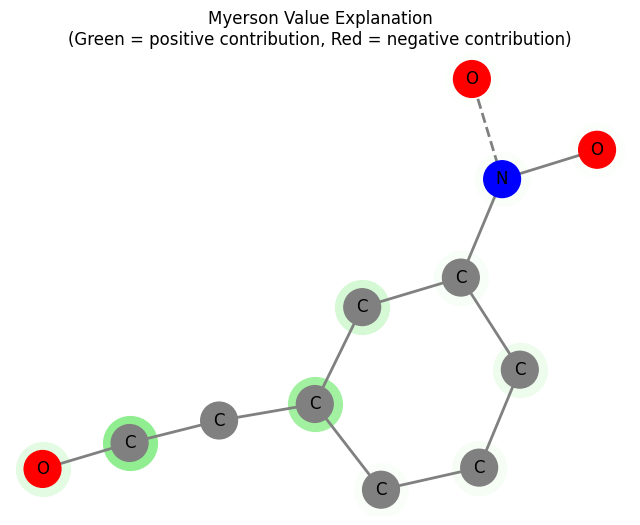

In [307]:
# --- Visualize Myerson value explanations ---
# We'll attach the Myerson values to the graph nodes and use the same visualization
# approach as with GNNExplainer.

# Scale the Myerson values to [-1, 1] range for visualization while preserving sign
# This allows visualization of both positive (green) and negative (red) contributions
values = np.array(list(myerson_values.values()))
max_abs_val = np.abs(values).max()
if max_abs_val > 0:
    scaled_values = abs(values) / max_abs_val  # Scale to [-1, 1] while preserving sign
else:
    scaled_values = np.zeros_like(values)

print(f'Myerson values range: [{values.min():.4f}, {values.max():.4f}]')
print(f'Scaled values range: [{scaled_values.min():.4f}, {scaled_values.max():.4f}]')

# Attach scaled values to graph nodes
for node_idx, scaled_value in zip(myerson_values.keys(), scaled_values):
    graph.nodes[node_idx]['node_explanation'] = scaled_value

# Visualize the explanation with diverging colors
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
pos = draw_graph(graph, ax)
draw_explanation(graph, pos, ax)
plt.title('Myerson Value Explanation\n(Green = positive contribution, Red = negative contribution)')
plt.axis('off')
plt.show()

**Interpreting Myerson Value Explanations.** The visualization above shows the Myerson value attribution for each atom in the molecule. Higher values (darker green) indicate atoms that contribute more to the model's prediction. Unlike the mask-based approaches of GNNExplainer and PGExplainer, Myerson values have a precise game-theoretic interpretation: they represent each atom's *fair share* of the total prediction, accounting for the cooperative structure defined by the molecular graph.

## **2.5** $\cdot$ 📚 *Multi-Explanation Graph Attention Network* (`MEGAN`)

The final structure-attribution method we'll explore takes a fundamentally different approach: rather than explaining predictions *post-hoc*, it produces explanations as an **intrinsic part of the forward pass**. The *Multi-Explanation Graph Attention Network* (MEGAN) was proposed by [Teufel *et al.*](https://link.springer.com/chapter/10.1007/978-3-031-44067-0_18) in 2023 and is implemented in the [graph_attention_student](https://github.com/aimat-lab/graph_attention_student) package.

**Core Methodology.** MEGAN is built on graph attention mechanisms where the attention weights serve a dual purpose: they both guide information flow during message passing *and* directly constitute the explanation. The key innovation lies in the use of **multiple explanation channels** &mdash; parallel attention heads that capture different aspects of the prediction. For regression tasks, two channels are used: one highlighting substructures that contribute *positively* to the prediction and another highlighting substructures that contribute *negatively*. For classification tasks, the number of channels matches the number of classes, with each channel highlighting features relevant to that particular class.

The architecture consists of several components:
1. **Parallel attention encoder**: Multiple layers of graph attention, where each layer contains K parallel attention heads (one per explanation channel). The attention weights from each head determine both the message passing and the node/edge importance for that channel.
2. **Importance-weighted pooling**: Rather than simple sum or mean pooling, MEGAN uses the attention weights to perform a weighted aggregation of node embeddings into a graph embedding &mdash; separately for each channel.
3. **Channel-specific projections**: Each channel's graph embedding is independently projected before being concatenated for the final prediction.

**Comparison to Other Methods.** Unlike GNNExplainer and PGExplainer which require a separate explanation step after prediction, MEGAN produces explanations *simultaneously* with the prediction. This has several advantages: (1) explanations are always consistent with the prediction since they use the same attention weights, (2) no additional computation is needed for explanation, and (3) the model can be trained with *explanation supervision* when ground-truth explanations are available, potentially improving both prediction accuracy and explanation quality.

The multi-channel nature of MEGAN explanations is particularly valuable for understanding complex structure-activity relationships. In molecular property prediction, different functional groups may contribute opposing effects (e.g., hydrophilic vs. hydrophobic groups for solubility), and MEGAN's separate channels can capture these distinct contributions.

**Implementation.** The `graph_attention_student` package provides a PyTorch Lightning-based implementation that integrates seamlessly with PyTorch Geometric data structures. The model can be trained on any graph-level regression or classification task.

**📝 Note.** Since MEGAN is a complete model architecture rather than a post-hoc explanation method, we cannot apply it to our existing `SimpleClassifier` model. Instead, we'll train a new MEGAN model on the same dataset and compare the explanations it produces.

In [308]:
from graph_attention_student.torch.megan import Megan
from visual_graph_datasets.processing.molecules import MoleculeProcessing

# --- Setting up MEGAN-compatible data processing ---
# MEGAN uses its own data processing pipeline from the visual_graph_datasets package.
# This processing creates node and edge features optimized for the MEGAN architecture.

processing = MoleculeProcessing()

# We'll convert our SMILES strings into the format expected by MEGAN
def graph_dict_from_smiles(smiles: str) -> dict:
    """
    Converts a SMILES string into a graph dictionary compatible with MEGAN.
    
    :param smiles: The SMILES string of the molecule.
    :returns: A dictionary containing graph data (node_indices, node_attributes, 
              edge_indices, edge_attributes).
    """
    return processing.process(smiles)


# --- Creating MEGAN-compatible dataset ---
# Convert the training and test data to MEGAN's expected format

from torch_geometric.data import Data as PyGData

def megan_data_from_smiles(smiles: str, target: float) -> PyGData:
    """
    Creates a PyTorch Geometric Data object from a SMILES string for use with MEGAN.
    
    :param smiles: The SMILES string of the molecule.
    :param target: The target value (0 or 1 for classification).
    :returns: A PyG Data object compatible with MEGAN.
    """
    graph_dict = graph_dict_from_smiles(smiles)
    
    data = PyGData(
        x=torch.tensor(graph_dict['node_attributes'], dtype=torch.float32),
        edge_index=torch.tensor(graph_dict['edge_indices'], dtype=torch.long).t().contiguous(),
        edge_attr=torch.tensor(graph_dict['edge_attributes'], dtype=torch.float32),
        y=torch.tensor([target], dtype=torch.float32),
    )
    return data


# Convert datasets
print('Converting dataset for MEGAN...')
megan_data_train = [
    megan_data_from_smiles(data_frame.iloc[idx]['smiles'], data_frame.iloc[idx]['Activity'])
    for idx in train_indices
]
megan_data_test = [
    megan_data_from_smiles(data_frame.iloc[idx]['smiles'], data_frame.iloc[idx]['Activity'])
    for idx in test_indices
]

print(f'Training set: {len(megan_data_train)} samples')
print(f'Test set: {len(megan_data_test)} samples')
print(f'Node features dimension: {megan_data_train[0].x.shape[1]}')
print(f'Edge features dimension: {megan_data_train[0].edge_attr.shape[1]}')

Converting dataset for MEGAN...
Training set: 6412 samples
Test set: 100 samples
Node features dimension: 10
Edge features dimension: 4


In [309]:
# --- Creating and training the MEGAN model ---
# MEGAN is a PyTorch Lightning module, so we can train it using the familiar Lightning Trainer.

# Create data loaders for MEGAN
megan_loader_train = DataLoader(megan_data_train, batch_size=64, shuffle=True, num_workers=4, prefetch_factor=3, drop_last=True)
megan_loader_test = DataLoader(megan_data_test, batch_size=32, shuffle=False)

# Create the MEGAN model
# For binary classification, we use 2 channels: one for the "positive" class contribution
# and one for the "negative" class contribution
megan_model = Megan(
    node_dim=megan_data_train[0].x.shape[1],
    edge_dim=megan_data_train[0].edge_attr.shape[1],
    units=[64, 64, 64],                    # Graph encoder layer sizes
    final_units=[64, 32, 1],               # Prediction MLP layer sizes
    num_channels=2,                         # Number of explanation channels
    importance_factor=0.0,                  # Set >0 for explanation supervision (if ground truth available)
    sparsity_factor=0.1,                    # Promotes sparse explanations
    prediction_mode='bce',                  # Binary cross-entropy for classification
    learning_rate=1e-3,
)

print('MEGAN model architecture:')
print(f'  Node input dim: {megan_model.node_dim}')
print(f'  Edge input dim: {megan_model.edge_dim}')
print(f'  Explanation channels: {megan_model.num_channels}')
print(f'  Prediction mode: {megan_model.prediction_mode}')

MEGAN model architecture:
  Node input dim: 10
  Edge input dim: 4
  Explanation channels: 2
  Prediction mode: bce


In [310]:
# --- Training the MEGAN model ---

megan_trainer = pl.Trainer(
    max_epochs=100,
    accelerator='auto',
    logger=True,
    enable_progress_bar=True,
)

megan_trainer.fit(
    model=megan_model,
    train_dataloaders=megan_loader_train,
    val_dataloaders=megan_loader_test,
)

megan_model.eval()
print('MEGAN model training complete.')

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /media/ssd2/Programming/xai_chem_review/.venv/lib/py ...
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ lay_embedd                │ Linear             │    704 │ train │     0 │
│ 1  │ lay_transform_1           │ Linear             │    176 │ train │     0 │
│ 2  │ lay_transform_2           │ Linear             │     16 │ train │     0 │
│ 3  │ encoder_layers            │ ModuleList         │  607 K │ train │     0 │
│ 4  │ lay_dropout_encoder       │ Dropout            │      0 │ train │     0 │
│ 5  │ lay_pool                  │ SumAggregation     │      0 │ train │     0 │
│ 6  │ lay_pool_mean             │ MeanAggregation    │      0 │ train │     0 │
│ 7  │ lay_pool_edge             │ MaxAggregation     │      0 │ train │     0 │
│ 8  │ lay_pool_importance       │ SumAggregation     │      0 │ train │     0 │
│ 9  │ importance_layers         │ ModuleList         │    130 │ train │     0 │
│ 10 │ channel_projection_layers │ ModuleList         │  8.6 K │ train │     0 │
│ 11 │ dense_layers              │ ModuleList         │ 10.6 K │ train │     0 │
│ 12 │ lay_act                   │ SiLU               │      0 │ train │     0 │
│ 13 │ lay_mask_expansion        │ MaskExpansionLayer │      0 │ train │     0 │
│ 14 │ projection_layers         │ ModuleList         │  1.1 M │ train │     0 │
│ 15 │ lay_final_dropout         │ Dropout            │      0 │ train │     0 │
│ 16 │ lay_act_final             │ Identity           │      0 │ train │     0 │
│ 17 │ loss_pred                 │ BCEWithLogitsLoss  │      0 │ train │     0 │
│ 18 │ variance_layers           │ ModuleList         │  4.8 K │ train │     0 │
│    │ other params              │ n/a                │      1 │ n/a   │   n/a │
└────┴───────────────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.8 M                                                                                            
Non-trainable params: 1                                                                                            
Total params: 1.8 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 223                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/media/ssd2/Programming/xai_chem_review/.venv/lib/python3.10/site-packages/torch_geometric/warnings.py:11: 
UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was 
not found
  warnings.warn(message)

`Trainer.fit` stopped: `max_epochs=100` reached.


MEGAN model training complete.


**MEGAN Model Evaluation.** Before using MEGAN to generate explanations, we should evaluate its predictive performance on the test set. This allows us to compare the predictive accuracy of MEGAN with our SimpleClassifier model, ensuring both models have learned meaningful patterns from the data.

In [311]:
# --- Evaluate MEGAN model on test set ---

megan_model.eval()

# Collect predictions and ground truth labels
megan_y_true = []
megan_y_pred_proba = []

with torch.no_grad():
    for batch in megan_loader_test:
        batch = batch.to(megan_model.device)
        # MEGAN forward returns a dictionary with 'graph_output' key
        output = megan_model.forward(batch)
        probs = torch.sigmoid(output['graph_output']).cpu().numpy()
        
        megan_y_pred_proba.extend(probs.flatten())
        megan_y_true.extend(batch.y.cpu().numpy().flatten())

megan_y_true = np.array(megan_y_true)
megan_y_pred_proba = np.array(megan_y_pred_proba)
megan_y_pred = (megan_y_pred_proba >= 0.5).astype(int)

# Calculate metrics
megan_accuracy = accuracy_score(megan_y_true, megan_y_pred)
megan_precision = precision_score(megan_y_true, megan_y_pred)
megan_recall = recall_score(megan_y_true, megan_y_pred)
megan_f1 = f1_score(megan_y_true, megan_y_pred)
megan_roc_auc = roc_auc_score(megan_y_true, megan_y_pred_proba)

print('MEGAN Model Evaluation on Test Set:')
print(f'  Accuracy:  {megan_accuracy:.4f}')
print(f'  Precision: {megan_precision:.4f}')
print(f'  Recall:    {megan_recall:.4f}')
print(f'  F1 Score:  {megan_f1:.4f}')
print(f'  ROC-AUC:   {megan_roc_auc:.4f}')

MEGAN Model Evaluation on Test Set:
  Accuracy:  0.8000
  Precision: 0.8261
  Recall:    0.7600
  F1 Score:  0.7917
  ROC-AUC:   0.8720


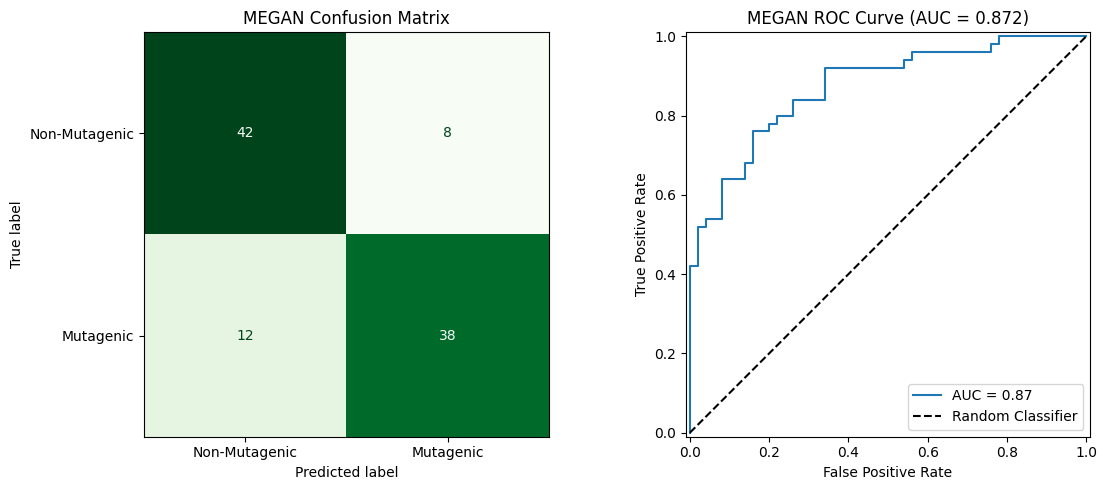

In [312]:
# --- Visualize MEGAN evaluation results ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
megan_cm = confusion_matrix(megan_y_true, megan_y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=megan_cm, display_labels=['Non-Mutagenic', 'Mutagenic'])
disp_cm.plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('MEGAN Confusion Matrix')

# ROC Curve
megan_fpr, megan_tpr, _ = roc_curve(megan_y_true, megan_y_pred_proba)
disp_roc = RocCurveDisplay(fpr=megan_fpr, tpr=megan_tpr, roc_auc=megan_roc_auc)
disp_roc.plot(ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_title(f'MEGAN ROC Curve (AUC = {megan_roc_auc:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

**Generating MEGAN Explanations.** With MEGAN, explanations are generated as part of the forward pass. The model returns not only the prediction but also the node and edge importance values for each explanation channel.

In [313]:
# --- Generating explanations with MEGAN ---
# We'll use the same molecule as in the previous examples for comparison.

from torch_geometric.data import Batch

SMILES = '[O-][N+](=O)c1cc(CCO)ccc1'

# Convert the molecule to MEGAN format
megan_data = megan_data_from_smiles(SMILES, target=1)

# IMPORTANT: MEGAN requires the `batch` attribute to be set, which indicates which graph
# each node belongs to. When passing a single Data object directly (without using DataLoader),
# this attribute is None. We use Batch.from_data_list() to properly create a batched object
# even for a single graph.
megan_batch = Batch.from_data_list([megan_data])

# Run forward pass to get prediction and explanations
with torch.no_grad():
    # MEGAN's forward method returns a dictionary with all outputs
    megan_output = megan_model.forward(megan_batch)

# Extract the results
prediction = torch.sigmoid(megan_output['graph_output']).item()
node_importance = megan_output['node_importance'].numpy()  # Shape: (num_nodes, num_channels)
edge_importance = megan_output['edge_importance'].numpy()  # Shape: (num_edges, num_channels)

print(f'Molecule: {SMILES}')
print(f'Prediction (probability of mutagenicity): {prediction:.4f}')
print(f'Node importance shape: {node_importance.shape}')
print(f'Edge importance shape: {edge_importance.shape}')
print(f'\nNode importance per channel:')
print(f'  Channel 0 (Non-Mutagenic): min={node_importance[:, 0].min():.4f}, max={node_importance[:, 0].max():.4f}')
print(f'  Channel 1 (Mutagenic):     min={node_importance[:, 1].min():.4f}, max={node_importance[:, 1].max():.4f}')

Molecule: [O-][N+](=O)c1cc(CCO)ccc1
Prediction (probability of mutagenicity): 0.4759
Node importance shape: (12, 2)
Edge importance shape: (24, 2)

Node importance per channel:
  Channel 0 (Non-Mutagenic): min=0.0080, max=1.0000
  Channel 1 (Mutagenic):     min=0.0316, max=0.1197


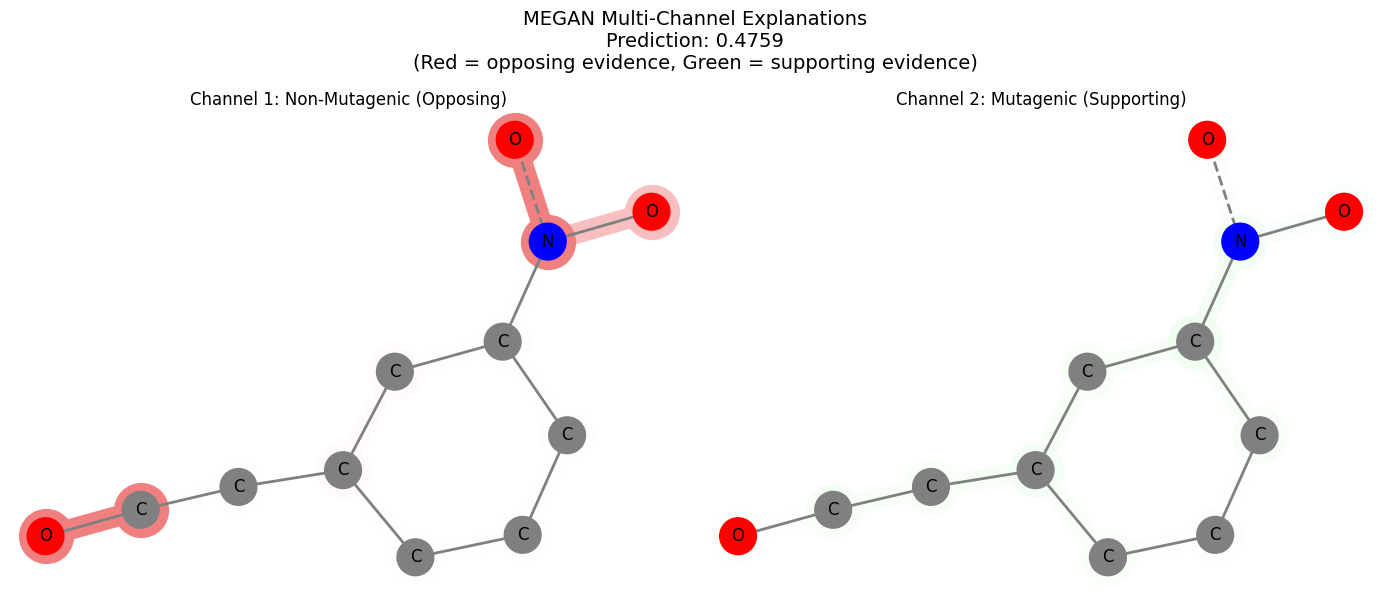

In [314]:
# --- Helper functions for MEGAN explanations ---

def graph_add_megan_explanation(
    graph: nx.Graph,
    node_importance: np.ndarray,
    edge_importance: np.ndarray,
    edge_index: np.ndarray,
) -> nx.Graph:
    """
    Attaches MEGAN multi-channel explanations to a networkx graph.
    
    For each channel, node explanations are stored under 'node_explanation_1', 
    'node_explanation_2', etc., and edge explanations under 'edge_explanation_1',
    'edge_explanation_2', etc.
    
    :param graph: The networkx Graph instance to attach explanations to.
    :param node_importance: Array of shape (num_nodes, num_channels) containing 
        node importance values for each channel.
    :param edge_importance: Array of shape (num_edges, num_channels) containing
        edge importance values for each channel.
    :param edge_index: Array of shape (2, num_edges) containing the edge indices
        from the PyG data format (bidirectional).
        
    :returns: The updated graph object with channel-specific explanation attributes.
    """
    num_channels = node_importance.shape[1]
    
    # Attach node explanations for each channel
    for channel in range(num_channels):
        node_key = f"node_explanation_{channel + 1}"
        for node_idx in range(min(len(node_importance), len(graph.nodes()))):
            graph.nodes[node_idx][node_key] = float(node_importance[node_idx, channel])
    
    # For edge explanations, we need to average bidirectional edges and map to networkx edges
    for channel in range(num_channels):
        edge_key = f"edge_explanation_{channel + 1}"
        
        # Collect edge importance values, averaging both directions
        edge_importance_dict = {}
        for idx in range(edge_index.shape[1]):
            u, v = int(edge_index[0, idx]), int(edge_index[1, idx])
            # Use canonical ordering (min, max) as key for undirected edge
            key = (min(u, v), max(u, v))
            if key not in edge_importance_dict:
                edge_importance_dict[key] = []
            edge_importance_dict[key].append(float(edge_importance[idx, channel]))
        
        # Average and assign to graph edges
        for (u, v), values in edge_importance_dict.items():
            avg_value = np.mean(values)
            if graph.has_edge(u, v):
                graph.edges[(u, v)][edge_key] = avg_value
            elif graph.has_edge(v, u):
                graph.edges[(v, u)][edge_key] = avg_value
    
    return graph


def draw_explanation_megan(
    graph: nx.Graph,
    pos: dict,
    ax: plt.Axes,
) -> None:
    """
    Draws MEGAN multi-channel explanations on a graph visualization.
    
    This function calls the base `draw_explanation` function twice - once for each
    channel - using different colors to distinguish the two explanation types:
    - Channel 1 (Non-Mutagenic): shown in red (lightcoral)
    - Channel 2 (Mutagenic): shown in green (lightgreen)
    
    The graph should have explanation attributes attached via `graph_add_megan_explanation`
    before calling this function.
    
    :param graph: The networkx graph with MEGAN explanation attributes 
        (node_explanation_1, node_explanation_2, edge_explanation_1, edge_explanation_2).
    :param pos: Dictionary of node positions.
    :param ax: The matplotlib axes to draw on.
    """
    # Draw Channel 1 (Non-Mutagenic) in red
    draw_explanation(
        graph, pos, ax,
        node_key="node_explanation_1",
        edge_key="edge_explanation_1",
        positive_color="lightcoral"
    )
    
    # Draw Channel 2 (Mutagenic) in green
    draw_explanation(
        graph, pos, ax,
        node_key="node_explanation_2",
        edge_key="edge_explanation_2",
        positive_color="lightgreen"
    )


# --- Visualizing MEGAN multi-channel explanations ---
# MEGAN provides separate explanations for each channel. We'll visualize both channels
# side by side to show how different parts of the molecule contribute to different aspects
# of the prediction.

# Create a fresh networkx graph for visualization
megan_graph = graph_from_smiles(SMILES)

# Attach MEGAN explanations to the graph using the helper function
graph_add_megan_explanation(
    megan_graph, 
    node_importance, 
    edge_importance, 
    megan_batch.edge_index.numpy()
)

# Create side-by-side visualization of both channels
# For binary classification, the channels correspond to the two classes:
# Channel 1 = Non-Mutagenic (class 0) -> Red (opposing evidence)
# Channel 2 = Mutagenic (class 1) -> Green (supporting evidence)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Channel 1: Non-Mutagenic
pos = draw_graph(megan_graph, axes[0])
draw_explanation(
    megan_graph, pos, axes[0],
    node_key="node_explanation_1",
    edge_key="edge_explanation_1",
    positive_color="lightcoral"
)
axes[0].set_title('Channel 1: Non-Mutagenic (Opposing)')
axes[0].axis('off')

# Channel 2: Mutagenic
pos = draw_graph(megan_graph, axes[1])
draw_explanation(
    megan_graph, pos, axes[1],
    node_key="node_explanation_2",
    edge_key="edge_explanation_2",
    positive_color="lightgreen"
)
axes[1].set_title('Channel 2: Mutagenic (Supporting)')
axes[1].axis('off')

plt.suptitle(f'MEGAN Multi-Channel Explanations\nPrediction: {prediction:.4f}\n(Red = opposing evidence, Green = supporting evidence)', fontsize=14)
plt.tight_layout()
plt.show()

**Interpreting MEGAN Explanations.** The visualization above demonstrates MEGAN's key advantage: the ability to provide **multi-channel explanations** that separately highlight different types of contributions to the prediction. For a binary classification task like mutagenicity prediction, the two channels correspond to the two classes:

- **Channel 0 (Non-Mutagenic)**: Highlights substructures that the model associates with non-mutagenic compounds. High importance values in this channel indicate atoms that contribute to the model predicting class 0.

- **Channel 1 (Mutagenic)**: Highlights substructures that the model associates with mutagenic compounds. In the context of Ames mutagenicity, this channel might highlight known mutagenic structural alerts such as nitro groups, aromatic amines, or other electrophilic centers.

**Key Differences from Post-hoc Methods.** Unlike GNNExplainer, PGExplainer, and Myerson values, which explain a *fixed* pre-trained model, MEGAN's explanations are an integral part of the model itself. This has important implications:

1. **Consistency**: The explanations are always consistent with the predictions because they use the same attention weights that determine how information flows through the network.

2. **Efficiency**: No additional computation is required to generate explanations &mdash; they come "for free" with each prediction.

3. **Trainability**: When ground-truth explanations are available (e.g., known mutagenic substructures), MEGAN can be trained with *explanation supervision* by setting `importance_factor > 0`. This can improve both the quality of explanations and potentially the accuracy of predictions.

4. **Channel Interpretability**: The multi-channel structure provides richer information than single-channel explanations, allowing domain experts to understand not just *what* is important but *how* different structural features contribute to each class.

**📝 Note.** The interpretation of channels depends on the task. For binary classification, each channel corresponds to one class. For regression tasks (e.g., predicting solubility), the channels separate positive and negative contributions to the predicted value. The `sparsity_factor` parameter controls how focused the explanations are &mdash; higher values produce sparser, more localized explanations at the cost of potentially missing some contributing substructures.

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 2.4** $\cdot$ MEGAN's `sparsity_factor` parameter controls how focused the explanations are. Higher values promote sparser explanations that highlight fewer atoms/bonds, while lower values allow more diffuse importance across the molecule.

Retrain the MEGAN model with different sparsity settings:
1. `sparsity_factor=0.0` (no sparsity regularization)
2. `sparsity_factor=0.5` (strong sparsity)
3. `sparsity_factor=1.0` (very strong sparsity)

For each setting, generate explanations for the nitro-containing molecule `'[O-][N+](=O)c1cc(CCO)ccc1'`. How does sparsity affect: (1) whether the nitro group is isolated as the key feature, and (2) the model's prediction accuracy? Is there a trade-off between explanation quality and predictive performance?
</div>

## **2.6** $\cdot$ 🔬 Comparison of Explanation Methods

Having explored four different structure-attribution methods, it is instructive to compare their explanations side-by-side on the same molecules. This comparison helps illustrate the different perspectives each method provides and highlights both their agreements and disagreements.

**Methods Compared:**
- **GNNExplainer**: Perturbation-based method that learns a mask to identify important substructures (node + edge explanations)
- **PGExplainer**: Parameterized explainer that trains an MLP to predict edge importance from node embeddings (edge explanations only)
- **Myerson Values**: Game-theoretic approach based on cooperative game theory (node explanations only)
- **MEGAN**: Self-explaining attention network with two channels - Mutagenic (green) and Non-Mutagenic (red) shown as a diverging colormap

**📝 Note.** Since GNNExplainer and PGExplainer explain our `SimpleClassifier` model while MEGAN is a separate model, the explanations may differ not only due to the explanation method but also due to differences in how the underlying models learned to make predictions.

In [315]:
# --- Helper function to generate all explanations for a molecule ---

from torch_geometric.explain.algorithm.utils import clear_masks

def generate_all_explanations(smiles: str, 
                               target: int,
                               gnn_model: SimpleGNNModel,
                               gnn_explainer: Explainer,
                               pg_explainer: Explainer,
                               megan_model: Megan,
                               myerson_wrapper: nn.Module,
                               ) -> dict:
    """
    Generate explanations from all methods for a given molecule.
    
    All computations are done on CPU to avoid device mismatch issues.
    
    If any method fails, it will print the error and return zeros for that method's
    explanations, allowing the comparison to continue with the other methods.
    
    :param smiles: SMILES string of the molecule
    :param target: Target class (0 or 1)
    :param gnn_model: The trained SimpleGNNModel (native torch module)
    :param gnn_explainer: The GNNExplainer instance
    :param pg_explainer: The trained PGExplainer instance
    :param megan_model: The trained MEGAN model
    :param myerson_wrapper: The wrapped model for Myerson value computation
    :returns: Dictionary containing explanations from all methods
    """
    results = {'smiles': smiles, 'target': target}
    
    # Move all models to CPU for consistent evaluation
    device = torch.device('cpu')
    gnn_model = gnn_model.to(device)
    gnn_model.eval()
    
    # Move explainer algorithms AND their model references to CPU
    gnn_explainer.algorithm = gnn_explainer.algorithm.to(device)
    gnn_explainer.model = gnn_explainer.model.to(device)
    pg_explainer.algorithm = pg_explainer.algorithm.to(device)
    pg_explainer.model = pg_explainer.model.to(device)
    
    # --- Prepare data (used by multiple methods) ---
    graph = graph_from_smiles(smiles)
    graph.graph['graph_labels'] = [target]
    data = data_from_graph(graph)
    num_nodes = data.x.shape[0]
    num_edges = data.edge_index.shape[1]
    
    # Store edge_index for later use in visualization
    results['edge_index'] = data.edge_index.numpy().copy()
    
    # Create batch on CPU
    loader = DataLoader([data], batch_size=1, shuffle=False)
    batch = next(iter(loader))  # Already on CPU
    
    # --- GNN Prediction ---
    try:
        with torch.no_grad():
            log_probs = gnn_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            probs = torch.exp(log_probs)
            gnn_pred = probs[0, 1].item()
        results['gnn_prediction'] = gnn_pred
    except Exception as e:
        print(f"    [GNN Prediction] Error: {e}")
        results['gnn_prediction'] = 0.5
    
    # --- GNNExplainer ---
    try:
        # Clean up model masks
        clear_masks(gnn_model)
        clear_masks(gnn_explainer.model)
        
        # Reset GNNExplainer's internal mask state to avoid size mismatches
        # from previous molecules that may have failed partway through
        gnn_explainer.algorithm.node_mask = None
        gnn_explainer.algorithm.hard_node_mask = None
        gnn_explainer.algorithm.edge_mask = None
        gnn_explainer.algorithm.hard_edge_mask = None
        
        explanation = gnn_explainer(
            x=batch.x,
            edge_index=batch.edge_index,
            edge_attr=batch.edge_attr,
            batch=batch.batch,
            target=batch.y.long(),
            index=0
        )
        results['gnnexplainer_node'] = explanation.node_mask.detach().numpy()
        if explanation.edge_mask is not None:
            results['gnnexplainer_edge'] = explanation.edge_mask.detach().numpy()
        else:
            results['gnnexplainer_edge'] = None
    except Exception as e:
        print(f"    [GNNExplainer] Error: {e}")
        results['gnnexplainer_node'] = np.zeros(num_nodes)
        results['gnnexplainer_edge'] = None
    finally:
        # Always clean up, even on error
        clear_masks(gnn_model)
        clear_masks(gnn_explainer.model)
        gnn_explainer.algorithm.node_mask = None
        gnn_explainer.algorithm.hard_node_mask = None
        gnn_explainer.algorithm.edge_mask = None
        gnn_explainer.algorithm.hard_edge_mask = None
    
    # --- PGExplainer ---
    try:
        clear_masks(gnn_model)
        clear_masks(pg_explainer.model)
        
        pg_explanation = pg_explainer(
            x=batch.x,
            edge_index=batch.edge_index,
            edge_attr=batch.edge_attr,
            batch=batch.batch,
            target=batch.y.long(),
        )
        results['pgexplainer_node'] = None
        if pg_explanation.edge_mask is not None:
            results['pgexplainer_edge'] = pg_explanation.edge_mask.detach().numpy()
        else:
            results['pgexplainer_edge'] = None
    except Exception as e:
        print(f"    [PGExplainer] Error: {e}")
        results['pgexplainer_node'] = None
        results['pgexplainer_edge'] = None
    finally:
        clear_masks(gnn_model)
        clear_masks(pg_explainer.model)
    
    # --- Myerson Values ---
    try:
        clear_masks(gnn_model)
        
        # Myerson wrapper should also be on CPU
        myerson_wrapper = myerson_wrapper.to(device)
        
        myerson_values = explain(data, myerson_wrapper, verbose=False)
        myerson_array = np.array([myerson_values[i] for i in range(len(myerson_values))])
        
        # Scale to [-1, 1] while preserving sign
        max_abs_val = np.abs(myerson_array).max()
        if max_abs_val > 0:
            myerson_scaled = myerson_array / max_abs_val
        else:
            myerson_scaled = np.zeros_like(myerson_array)
        results['myerson_node'] = myerson_scaled
        results['myerson_edge'] = None
    except Exception as e:
        print(f"    [Myerson Values] Error: {e}")
        results['myerson_node'] = np.zeros(num_nodes)
        results['myerson_edge'] = None
    
    # --- MEGAN ---
    try:
        # Move MEGAN to CPU as well
        megan_model = megan_model.to(device)
        megan_model.eval()
        
        megan_data = megan_data_from_smiles(smiles, target)
        megan_batch = Batch.from_data_list([megan_data])  # Already on CPU
        
        with torch.no_grad():
            megan_output = megan_model.forward(megan_batch)
        
        megan_pred = torch.sigmoid(megan_output['graph_output']).item()
        results['megan_prediction'] = megan_pred
        
        results['megan_node_ch0'] = megan_output['node_importance'][:, 0].numpy()
        results['megan_node_ch1'] = megan_output['node_importance'][:, 1].numpy()
        results['megan_edge_ch0'] = megan_output['edge_importance'][:, 0].numpy()
        results['megan_edge_ch1'] = megan_output['edge_importance'][:, 1].numpy()
        results['megan_edge_index'] = megan_batch.edge_index.numpy()
    except Exception as e:
        print(f"    [MEGAN] Error: {e}")
        results['megan_prediction'] = 0.5
        results['megan_node_ch0'] = np.zeros(num_nodes)
        results['megan_node_ch1'] = np.zeros(num_nodes)
        results['megan_edge_ch0'] = None
        results['megan_edge_ch1'] = None
        results['megan_edge_index'] = None
    
    # Final cleanup
    clear_masks(gnn_model)
    clear_masks(gnn_explainer.model)
    clear_masks(pg_explainer.model)
    
    return results

In [316]:
# Cell intentionally left empty - utility functions moved to plot_explanation_comparison

Utility functions defined:
  - edge_explanations_from_nodes(node_values, edge_index, aggregation='mean')
  - node_explanations_from_edges(edge_values, edge_index, num_nodes, aggregation='mean')


In [317]:
# --- Visualization function for side-by-side comparison ---

def graph_add_node_explanations(
    graph: nx.Graph,
    node_values: np.ndarray,
    node_key: str = "node_explanation",
) -> nx.Graph:
    """
    Attaches node explanation values from a numpy array to a networkx graph.
    
    :param graph: The networkx Graph instance.
    :param node_values: Array of shape (num_nodes,) containing explanation values.
    :param node_key: The key to use for storing node explanations.
    :returns: The updated graph object.
    """
    for node_idx in range(min(len(node_values), len(graph.nodes()))):
        graph.nodes[node_idx][node_key] = float(node_values[node_idx])
    return graph


def graph_add_edge_explanations(
    graph: nx.Graph,
    edge_values: np.ndarray,
    edge_index: np.ndarray,
    edge_key: str = "edge_explanation",
) -> nx.Graph:
    """
    Attaches edge explanation values from a numpy array to a networkx graph.
    
    Handles the mapping from PyG bidirectional edge indices to networkx undirected edges
    by averaging the values from both directions.
    
    :param graph: The networkx Graph instance.
    :param edge_values: Array of shape (num_edges,) containing explanation values.
    :param edge_index: Array of shape (2, num_edges) containing edge indices.
    :param edge_key: The key to use for storing edge explanations.
    :returns: The updated graph object.
    """
    # Collect edge values, averaging both directions for undirected edges
    edge_value_dict = {}
    for idx in range(edge_index.shape[1]):
        u, v = int(edge_index[0, idx]), int(edge_index[1, idx])
        key = (min(u, v), max(u, v))  # Canonical ordering
        if key not in edge_value_dict:
            edge_value_dict[key] = []
        edge_value_dict[key].append(float(edge_values[idx]))
    
    # Average and assign to graph edges
    for (u, v), values in edge_value_dict.items():
        avg_value = np.mean(values)
        if graph.has_edge(u, v):
            graph.edges[(u, v)][edge_key] = avg_value
        elif graph.has_edge(v, u):
            graph.edges[(v, u)][edge_key] = avg_value
    
    return graph


def plot_explanation_comparison(smiles: str,
                                 explanations: dict,
                                 figsize: tuple = (20, 5),
                                 aggregation: str = 'mean') -> None:
    """
    Create a side-by-side comparison of explanations from different methods.
    
    Uses networkx graphs and the `cast_explanations` function to derive missing
    explanation types (node or edge) when a method only provides one.
    
    For MEGAN, both channels are visualized using `draw_explanation_megan`, which
    shows channel 1 (Non-Mutagenic) in red and channel 2 (Mutagenic) in green.
    
    :param smiles: SMILES string of the molecule
    :param explanations: Dictionary containing explanations from all methods
    :param figsize: Figure size tuple
    :param aggregation: Aggregation function for deriving missing explanations
    """
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    
    # Method configurations
    methods = [
        {
            'name': 'GNNExplainer',
            'node_key_src': 'gnnexplainer_node',
            'edge_key_src': 'gnnexplainer_edge',
            'edge_index_key': 'edge_index',
            'color': 'lightgreen',
            'use_absolute': False,
        },
        {
            'name': 'PGExplainer',
            'node_key_src': 'pgexplainer_node',
            'edge_key_src': 'pgexplainer_edge',
            'edge_index_key': 'edge_index',
            'color': 'lightgreen',
            'use_absolute': False,
        },
        {
            'name': 'Myerson Values',
            'node_key_src': 'myerson_node',
            'edge_key_src': 'myerson_edge',
            'edge_index_key': 'edge_index',
            'color': 'lightgreen',
            'use_absolute': True,  # Use absolute values for Myerson
        },
        {
            'name': 'MEGAN',
            'is_megan': True,
        },
    ]
    
    for ax, method in zip(axes, methods):
        
        # Create a fresh graph for each method
        graph = graph_from_smiles(smiles)
        
        if method.get('is_megan', False):
            # --- MEGAN: Handle multi-channel explanations ---
            node_ch0 = explanations.get('megan_node_ch0')
            node_ch1 = explanations.get('megan_node_ch1')
            edge_ch0 = explanations.get('megan_edge_ch0')
            edge_ch1 = explanations.get('megan_edge_ch1')
            megan_edge_index = explanations.get('megan_edge_index')
            
            # Attach channel 1 (Non-Mutagenic)
            if node_ch0 is not None:
                graph_add_node_explanations(graph, node_ch0, "node_explanation_1")
            if edge_ch0 is not None and megan_edge_index is not None:
                graph_add_edge_explanations(graph, edge_ch0, megan_edge_index, "edge_explanation_1")
            
            # Attach channel 2 (Mutagenic)
            if node_ch1 is not None:
                graph_add_node_explanations(graph, node_ch1, "node_explanation_2")
            if edge_ch1 is not None and megan_edge_index is not None:
                graph_add_edge_explanations(graph, edge_ch1, megan_edge_index, "edge_explanation_2")
            
            # Cast missing explanations for each channel
            cast_explanations(graph, "node_explanation_1", "edge_explanation_1", aggregation)
            cast_explanations(graph, "node_explanation_2", "edge_explanation_2", aggregation)
            
            # Draw the graph and MEGAN explanations
            pos = draw_graph(graph, ax)
            draw_explanation_megan(graph, pos, ax)
            
            node_provided = node_ch0 is not None
            edge_provided = edge_ch0 is not None
            
        else:
            # --- Standard single-channel methods ---
            node_values = explanations.get(method['node_key_src'])
            edge_values = explanations.get(method['edge_key_src'])
            edge_index = explanations.get(method['edge_index_key'])
            
            # Apply absolute value if needed (for Myerson)
            if method.get('use_absolute', False):
                if node_values is not None:
                    node_values = np.abs(node_values)
                if edge_values is not None:
                    edge_values = np.abs(edge_values)
            
            # Attach explanations to graph
            if node_values is not None:
                graph_add_node_explanations(graph, node_values)
            if edge_values is not None and edge_index is not None:
                graph_add_edge_explanations(graph, edge_values, edge_index)
            
            # Cast missing explanations
            cast_explanations(graph, aggregation=aggregation)
            
            # Draw the graph and explanations
            pos = draw_graph(graph, ax)
            draw_explanation(graph, pos, ax, positive_color=method['color'])
            
            node_provided = node_values is not None
            edge_provided = edge_values is not None
        
        # Add indicator showing what was provided vs derived
        node_indicator = "N" if node_provided else "n"
        edge_indicator = "E" if edge_provided else "e"
        indicator = f" ({node_indicator}+{edge_indicator})"
        ax.set_title(method['name'] + indicator, fontsize=12)
        ax.axis('off')
    
    # Add overall title with predictions
    target_label = "Mutagenic" if explanations['target'] == 1 else "Non-Mutagenic"
    title = f"Molecule: {smiles}\n"
    title += f"Ground Truth: {target_label} | "
    title += f"GNN Pred: {explanations['gnn_prediction']:.3f} | "
    title += f"MEGAN Pred: {explanations['megan_prediction']:.3f}"
    fig.suptitle(title, fontsize=14, y=1.02)
    
    plt.tight_layout()
    plt.show()

Generating explanations for comparison molecules...
This may take a moment due to Myerson value computation...

Processing molecule 1/4: [O-][N+](=O)c1cc(CCO)ccc1


[2026-01-15 15:12:03,902 - INFO] Calculating exact Myerson values.
[2026-01-15 15:12:03,902 - INFO] using device cuda:0
[2026-01-15 15:12:03,904 - INFO] Calculating number of coalitions.
[2026-01-15 15:12:03,905 - INFO] Number of coalitions: 4096
[2026-01-15 15:12:03,905 - INFO] Calculating number of graph restricted coalitions.
[2026-01-15 15:12:04,029 - INFO] Removing dublicates from 12353 graph restricted coalitions.
[2026-01-15 15:12:04,031 - INFO] Number of graph restricted coalitions: 252
[2026-01-15 15:12:04,032 - INFO] Calculating worth of graph restricted coalitions.
[2026-01-15 15:12:04,461 - INFO] Mapping coalitions to worth.
[2026-01-15 15:12:04,465 - INFO] Calculating Myerson values.
[2026-01-15 15:12:04,478 - INFO] Myerson Values:
	0: 0.0725
	1: 0.1115
	2: -0.0506
	3: -0.1418
	4: 0.7543
	5: 1.6661
	6: 0.0060
	7: -1.9763
	8: -0.5063
	9: -0.1104
	10: -0.1750
	11: 0.3052

/tmp/ipykernel_4116208/1190425207.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a s

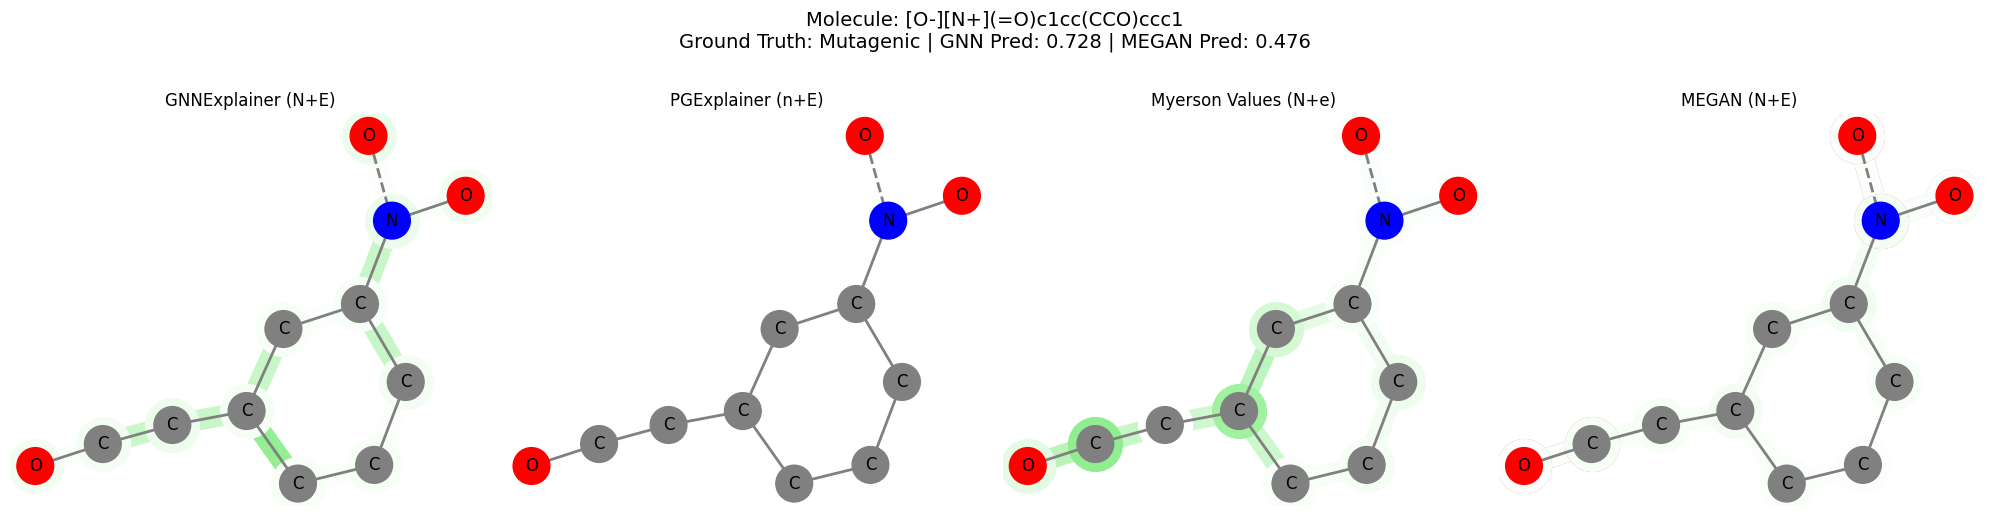

Processing molecule 2/4: Nc1ccc(O)cc1


[2026-01-15 15:12:06,001 - INFO] Calculating exact Myerson values.
[2026-01-15 15:12:06,002 - INFO] using device cuda:0
[2026-01-15 15:12:06,003 - INFO] Calculating number of coalitions.
[2026-01-15 15:12:06,004 - INFO] Number of coalitions: 256
[2026-01-15 15:12:06,004 - INFO] Calculating number of graph restricted coalitions.
[2026-01-15 15:12:06,011 - INFO] Removing dublicates from 517 graph restricted coalitions.
[2026-01-15 15:12:06,011 - INFO] Number of graph restricted coalitions: 73
[2026-01-15 15:12:06,012 - INFO] Calculating worth of graph restricted coalitions.
[2026-01-15 15:12:06,141 - INFO] Mapping coalitions to worth.
[2026-01-15 15:12:06,143 - INFO] Calculating Myerson values.
[2026-01-15 15:12:06,145 - INFO] Myerson Values:
	0: -0.5905
	1: -0.9465
	2: 0.3490
	3: 0.1903
	4: -0.3325
	5: -1.0116
	6: 0.1903
	7: 0.3490



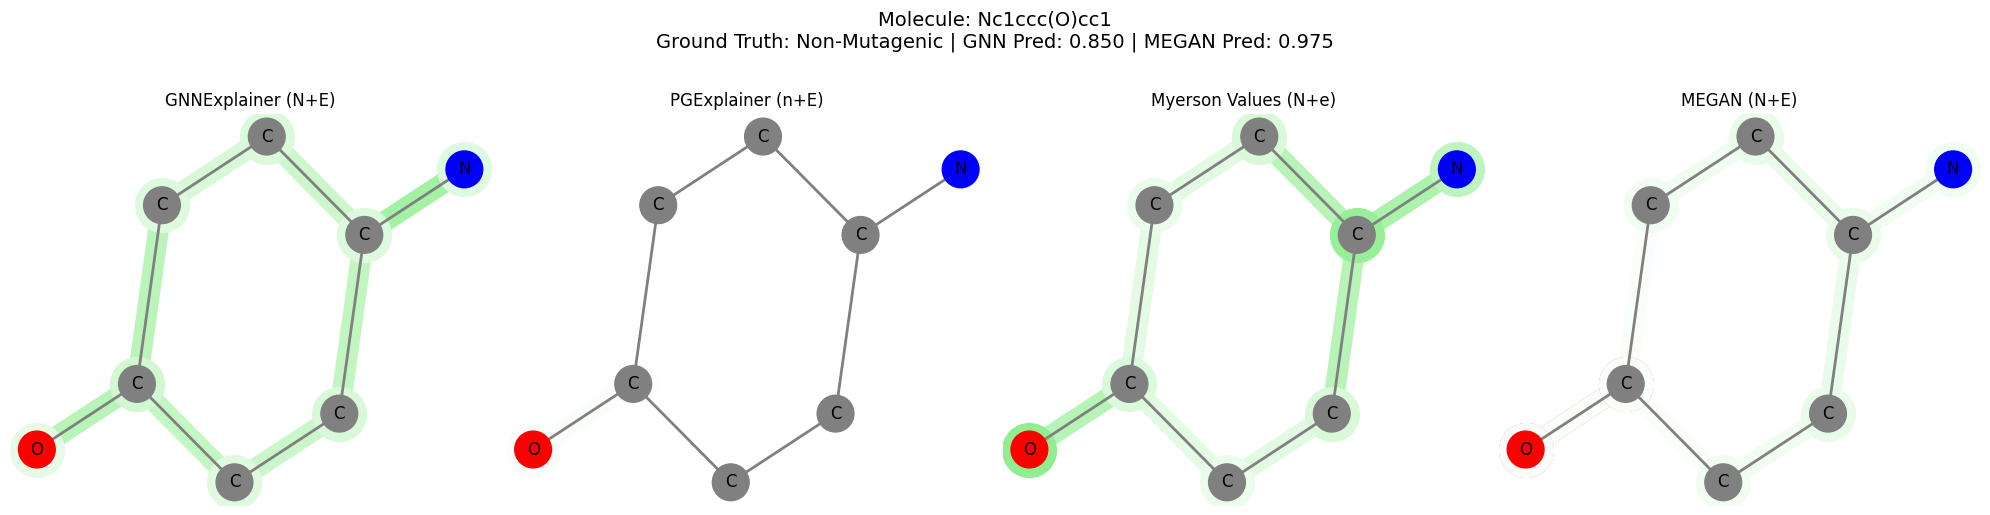

Processing molecule 3/4: Clc1ccc(Cl)c(Cl)c1


[2026-01-15 15:12:07,547 - INFO] Calculating exact Myerson values.
[2026-01-15 15:12:07,548 - INFO] using device cuda:0
[2026-01-15 15:12:07,550 - INFO] Calculating number of coalitions.
[2026-01-15 15:12:07,551 - INFO] Number of coalitions: 512
[2026-01-15 15:12:07,551 - INFO] Calculating number of graph restricted coalitions.
[2026-01-15 15:12:07,564 - INFO] Removing dublicates from 1161 graph restricted coalitions.
[2026-01-15 15:12:07,565 - INFO] Number of graph restricted coalitions: 114
[2026-01-15 15:12:07,565 - INFO] Calculating worth of graph restricted coalitions.
[2026-01-15 15:12:07,764 - INFO] Mapping coalitions to worth.
[2026-01-15 15:12:07,765 - INFO] Calculating Myerson values.
[2026-01-15 15:12:07,767 - INFO] Myerson Values:
	0: -1.5534
	1: 0.7052
	2: 0.0000
	3: 0.2091
	4: 0.6232
	5: -1.4069
	6: 0.6989
	7: -1.4443
	8: 0.5687



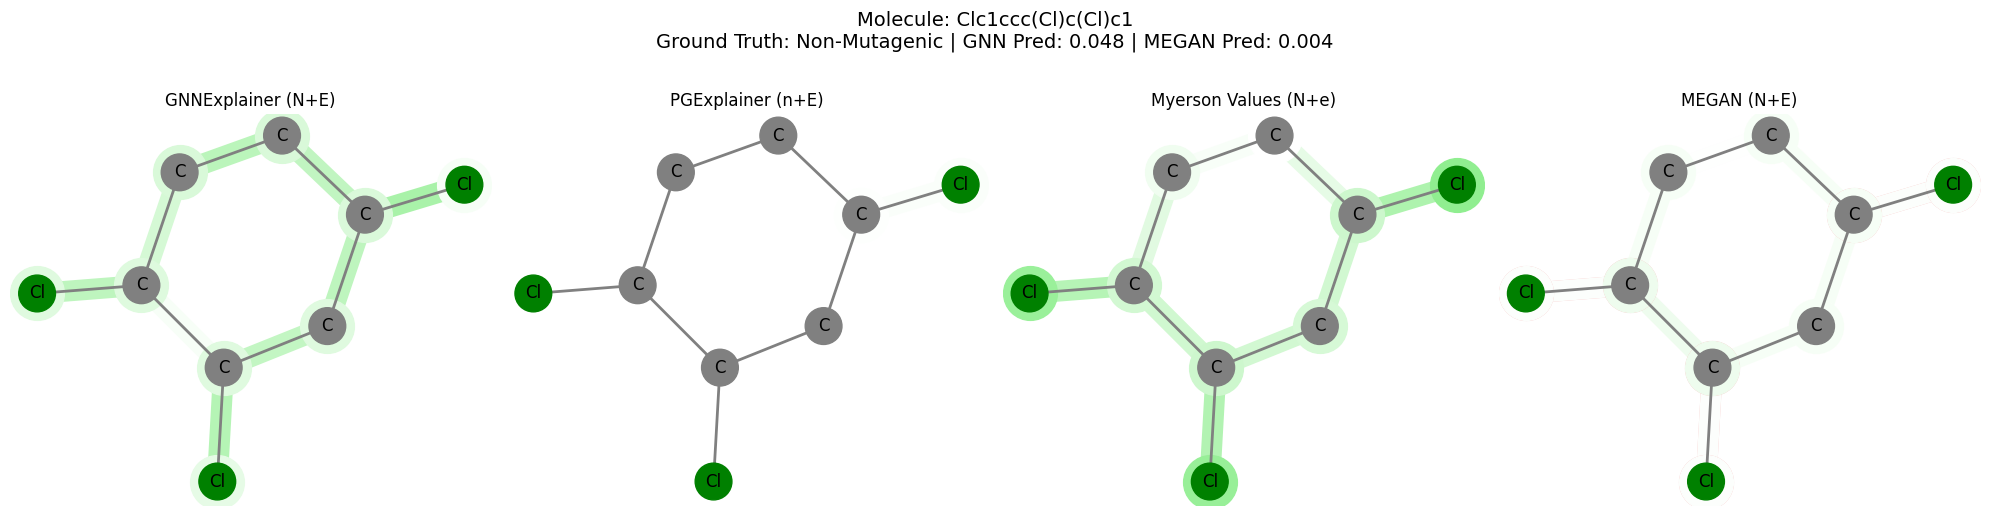

Processing molecule 4/4: CC(=O)Nc1ccc(O)cc1


[2026-01-15 15:12:09,254 - INFO] Calculating exact Myerson values.
[2026-01-15 15:12:09,255 - INFO] using device cuda:0
[2026-01-15 15:12:09,257 - INFO] Calculating number of coalitions.
[2026-01-15 15:12:09,258 - INFO] Number of coalitions: 2048
[2026-01-15 15:12:09,258 - INFO] Calculating number of graph restricted coalitions.
[2026-01-15 15:12:09,315 - INFO] Removing dublicates from 5665 graph restricted coalitions.
[2026-01-15 15:12:09,317 - INFO] Number of graph restricted coalitions: 175
[2026-01-15 15:12:09,317 - INFO] Calculating worth of graph restricted coalitions.
[2026-01-15 15:12:09,617 - INFO] Mapping coalitions to worth.
[2026-01-15 15:12:09,619 - INFO] Calculating Myerson values.
[2026-01-15 15:12:09,626 - INFO] Myerson Values:
	0: -3.2970
	1: -0.7627
	2: -0.6363
	3: 0.4148
	4: 0.2516
	5: -0.0677
	6: 0.2556
	7: -0.2020
	8: -0.9753
	9: 0.2556
	10: -0.0677



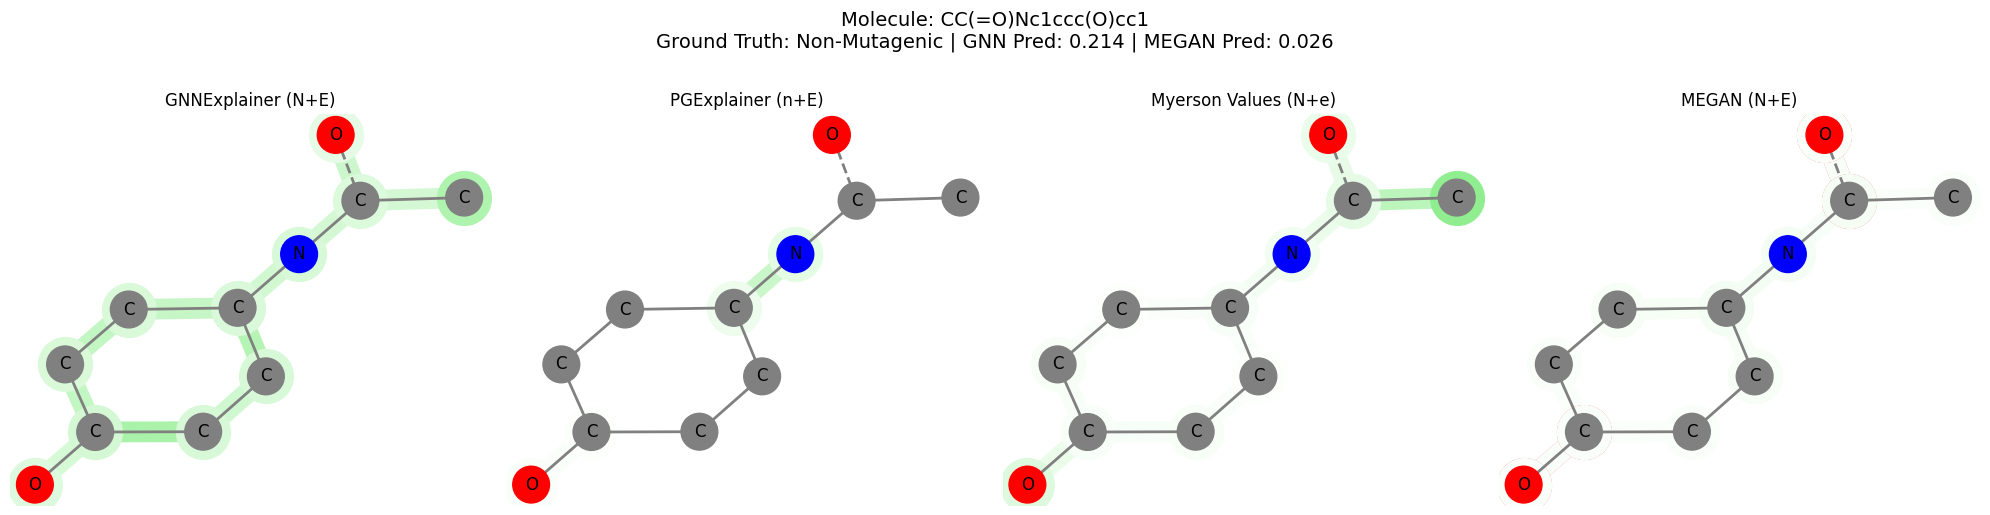

In [318]:
# --- Generate and compare explanations for several example molecules ---

# Select a few interesting molecules from the test set for comparison
# We'll pick molecules with different characteristics and predictions

comparison_molecules = [
    # Molecule with nitro group (known mutagenic alert)
    '[O-][N+](=O)c1cc(CCO)ccc1',
    # Simple aromatic amine
    'Nc1ccc(O)cc1',
    # Halogenated compound
    'Clc1ccc(Cl)c(Cl)c1',
    # Molecule with multiple functional groups
    'CC(=O)Nc1ccc(O)cc1',
]

print("Generating explanations for comparison molecules...")
print("This may take a moment due to Myerson value computation...\n")

for i, smiles in enumerate(comparison_molecules):
    print(f"Processing molecule {i+1}/{len(comparison_molecules)}: {smiles}")
    
    # Determine target from dataset if available, otherwise assume mutagenic for demo
    target = 1
    matching_rows = data_frame[data_frame['smiles'] == smiles]
    if len(matching_rows) > 0:
        target = int(matching_rows.iloc[0]['Activity'])
    
    try:
        explanations = generate_all_explanations(
            smiles=smiles,
            target=target,
            gnn_model=model.model.copy(),  # Use the native torch module
            gnn_explainer=explainer,
            pg_explainer=pg_explainer,
            megan_model=megan_model,
            myerson_wrapper=wrapped_model,
        )
        
        plot_explanation_comparison(smiles, explanations)
        
    except Exception as e:
        print(f"  Error processing molecule: {e}")
        continue

### Observations and Discussion

The side-by-side comparison reveals several interesting patterns:

**Agreement Between Methods:**
- All methods tend to highlight chemically meaningful substructures, such as nitro groups, aromatic rings, and heteroatoms.
- For molecules with known mutagenic alerts (e.g., nitro groups), most methods correctly identify these regions as important.

**Differences Between Methods:**

1. **GNNExplainer** produces smooth, continuous importance values and tends to highlight connected subgraphs. As a perturbation-based method, it identifies regions whose removal would most affect the prediction.

2. **Myerson Values** provide attributions grounded in game theory, ensuring fairness properties like efficiency (attributions sum to the prediction). The explanations may appear different because they measure each atom's *marginal contribution* rather than importance for maintaining a prediction.

3. **MEGAN Channels** show complementary information:
   - The **Non-Mutagenic channel** highlights substructures associated with non-toxic compounds
   - The **Mutagenic channel** highlights substructures associated with toxicity
   - This dual-channel view can reveal how different parts of a molecule contribute to opposing outcomes

**Key Takeaways:**

- No single explanation method is universally "best" &mdash; each provides a different perspective on model behavior
- Comparing multiple methods can increase confidence when they agree on important substructures
- Disagreements between methods may indicate regions where model behavior is complex or where different methods capture different aspects of importance
- Domain knowledge is essential for interpreting explanations &mdash; chemists can validate whether highlighted substructures correspond to known structure-activity relationships

## **2.7** $\cdot$ 🔬 Discussion and Limitations

The structure-attribution methods presented in this tutorial offer direct insight into which atoms and bonds a graph neural network considers important for its predictions. However, several considerations should guide the interpretation and application of these explanations.

**Explanation Faithfulness.** A central question for any explanation method is whether the highlighted substructures actually reflect the model's decision-making process. For post-hoc methods such as GNNExplainer, PGExplainer, and Myerson values, explanations are generated by analyzing a model that was not designed with interpretability in mind. These methods make assumptions that may not perfectly align with the model's internal computations &mdash; for instance, perturbation-based approaches assume that masking nodes or edges approximates their removal, but message passing on a partially masked graph behaves differently than on a truly smaller molecular graph. Intrinsic explanation methods like MEGAN address this concern by producing explanations as a direct byproduct of the prediction itself: the same attention weights that generate the explanation also determine how information flows through the network. This architectural coupling is intended to increase the alignment between the explanation and actual model behavior. However, intrinsic methods require committing to a specific model architecture, whereas post-hoc methods can be applied to any pre-trained GNN. The choice between these paradigms involves a trade-off between explanation faithfulness and flexibility.

**Hyperparameter Sensitivity and Method Agreement.** The explanations produced by structure-attribution methods can depend substantially on hyperparameter choices &mdash; the sparsity regularization strength in PGExplainer, the number of optimization epochs in GNNExplainer, or the sparsity factor in MEGAN all influence which substructures are highlighted and how focused the explanations appear. Importantly, different hyperparameter settings can lead to markedly different explanations *from the same method* on the same molecule, not only disagreements between methods. When comparing explanations across methods, as demonstrated in the comparison section above, apparent disagreements may therefore reflect differences in configuration rather than fundamental differences in what the methods reveal. This underscores the importance of actively engaging with the explanation process rather than treating it as a black-box procedure. Practitioners should experiment with hyperparameter settings and verify that explanations behave sensibly on molecules with known structure-activity relationships.

**Practical Implications.** Given the potential for disagreement both between and within methods, it is advisable to apply multiple explanation approaches and examine where they converge or diverge. Consistent highlighting of the same substructure across different methods can increase confidence in its relevance, while disagreement may warrant closer investigation. More broadly, explanation methods should be understood as approximative tools rather than authoritative oracles &mdash; they can be as flawed or biased as the models they aim to explain. Treating explanations as one source of evidence among many, rather than definitive answers, helps avoid overconfidence in potentially misleading results. Finally, computational costs should inform method selection. GNNExplainer and Myerson values require substantial computation for each individual molecule, making them impractical when explanations are needed for large numbers of compounds. In such scenarios, methods that amortize the computational cost through pre-training &mdash; such as PGExplainer or MEGAN &mdash; offer more scalable alternatives.

## **References**

**Datasets**

- Hansen, K., Mika, S., Schroeter, T., Sutter, A., ter Laak, A., Steger-Hartmann, T., Heinrich, N., & Müller, K.-R. (2009). Benchmark data set for in silico prediction of Ames mutagenicity. *Journal of Chemical Information and Modeling*, 49(9), 2077–2081. https://doi.org/10.1021/ci900161g

**Methods**

- Ying, Z., Bourgeois, D., You, J., Zitnik, M., & Leskovec, J. (2019). GNNExplainer: Generating explanations for graph neural networks. *Advances in Neural Information Processing Systems*, 32. https://arxiv.org/abs/1903.03894

- Luo, D., Cheng, W., Xu, D., Yu, W., Zong, B., Chen, H., & Zhang, X. (2020). Parameterized explainer for graph neural network. *Advances in Neural Information Processing Systems*, 33, 19620–19631. https://arxiv.org/abs/2011.04573

- Homberg, S. K. R., Modlich, M. L., Menke, J., Morris, G. M., Risse, B., & Koch, O. (2024). Interpreting graph neural networks with Myerson values for cheminformatics approaches. *ChemRxiv* (preprint). https://chemrxiv.org/engage/chemrxiv/article-details/668c3885c9c6a5c07aaca81e | [GitHub](https://github.com/kochgroup/myerson)

- Teufel, J., Torresi, L., Reiser, P., & Friederich, P. (2023). MEGAN: Multi-explanation graph attention network. In *Explainable Artificial Intelligence (xAI 2023)*, Communications in Computer and Information Science, vol. 1903, pp. 338–360. Springer. https://link.springer.com/chapter/10.1007/978-3-031-44067-0_18 | [GitHub](https://github.com/aimat-lab/graph_attention_student)

**Software**

- Landrum, G. et al. (2024). RDKit: Open-source cheminformatics software. https://www.rdkit.org

- Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., ... & Chintala, S. (2019). PyTorch: An imperative style, high-performance deep learning library. *Advances in Neural Information Processing Systems*, 32. https://pytorch.org

- Falcon, W. et al. (2019). PyTorch Lightning. https://lightning.ai/docs/pytorch/stable/

- Fey, M., & Lenssen, J. E. (2019). Fast graph representation learning with PyTorch Geometric. In *ICLR Workshop on Representation Learning on Graphs and Manifolds*. https://pytorch-geometric.readthedocs.io

- Hagberg, A. A., Schult, D. A., & Swart, P. J. (2008). Exploring network structure, dynamics, and function using NetworkX. In *Proceedings of the 7th Python in Science Conference*, pp. 11–15. https://networkx.org